# Predicting Airbnb Listing Prices with MLflow and AWS S3
### StayWise Data Science Team — AML-3303 Assignment 2

**Objective:** Build a clean, reproducible machine learning pipeline that predicts the optimal nightly price for new Airbnb listings.  
**Tools:** Python · pandas · scikit-learn · MLflow · boto3 (AWS S3)  
**Dataset:** `s3://staywise1/airbnb/raw_data/AB_NYC_2019.csv`

---
| Step | Description |
|------|-------------|
| 1 | Retrieve the dataset from AWS S3 |
| 2 | Exploratory Data Analysis (EDA) |
| 3 | Data Preprocessing & Feature Engineering |
| 4 | Model Training & MLflow Experiment Tracking |
| 5 | Model Evaluation & Selection |
| 6 | Register Best Model in MLflow Model Registry |

---
## Step 1 — Retrieve the Airbnb Dataset from AWS S3

**Goal:** Load the raw CSV from the public S3 bucket `staywise1` into a pandas DataFrame, then perform an initial structural inspection before any cleaning or transformation.

**Approach:**
- Use **`boto3`** (official AWS SDK for Python) to stream the S3 object directly into memory — no local file download needed.
- The bucket is **publicly readable**, so requests are sent **unsigned** using `Config(signature_version=UNSIGNED)` — no AWS credentials required.
- The loader is wrapped in a dedicated function with type hints and a docstring (SDLC: modularity, readability, testability).
- Python's **`logging`** module replaces bare `print` statements (SDLC: observability).

In [10]:
# Install required libraries (run once)
# boto3       : AWS SDK — stream objects from S3
# pandas      : DataFrame manipulation
# numpy       : numerical operations
# matplotlib  : base plotting
# seaborn     : statistical visualisations
# scikit-learn: preprocessing utilities (encoders, scalers)
# mlflow      : experiment tracking (used from Step 4 onwards)
%pip install --quiet boto3 pandas numpy matplotlib seaborn scikit-learn mlflow

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.0 -> 26.0.1
[notice] To update, run: C:\Users\jham3\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [11]:
import io
import logging
import os

import boto3
import pandas as pd
from botocore.exceptions import BotoCoreError, ClientError

# ---------------------------------------------------------------------------
# Logging  — structured, level-aware output instead of bare print() calls
# ---------------------------------------------------------------------------
logging.basicConfig(
    level=logging.INFO,
    format="%(asctime)s  %(levelname)-8s  %(message)s",
    datefmt="%Y-%m-%d %H:%M:%S",
)
logger = logging.getLogger(__name__)

logger.info("Libraries loaded successfully.")

2026-04-02 23:03:38  INFO      Libraries loaded successfully.


In [12]:
# ---------------------------------------------------------------------------
# S3 Configuration — source of truth for bucket / key paths
# Credentials are intentionally NOT stored here.
# boto3 resolves them automatically from:
#   1. Environment variables : AWS_ACCESS_KEY_ID / AWS_SECRET_ACCESS_KEY
#   2. ~/.aws/credentials     : populated by `aws configure`
#   3. IAM Instance Role      : automatic when running on EC2/SageMaker
# ---------------------------------------------------------------------------
S3_BUCKET: str = "staywise1"
S3_KEY: str    = "airbnb/raw_data/AB_NYC_2019.csv"
AWS_REGION: str = os.environ.get("AWS_DEFAULT_REGION", "us-east-1")

logger.info("S3 source  → s3://%s/%s", S3_BUCKET, S3_KEY)
logger.info("AWS region → %s", AWS_REGION)

2026-04-02 23:03:41  INFO      S3 source  → s3://staywise1/airbnb/raw_data/AB_NYC_2019.csv
2026-04-02 23:03:41  INFO      AWS region → us-east-1


In [13]:
from botocore import UNSIGNED
from botocore.config import Config


def load_data_from_s3(bucket: str, key: str, region: str = "us-east-1") -> pd.DataFrame:
    """
    Stream a publicly accessible CSV file from AWS S3 into a pandas DataFrame.

    The bucket is configured for public read access, so requests are sent
    unsigned (no AWS credentials required).  This is achieved by passing
    ``Config(signature_version=UNSIGNED)`` to the boto3 client, which skips
    the Signature Version 4 signing step entirely.

    Parameters
    ----------
    bucket : str
        Name of the public S3 bucket (e.g. 'staywise1').
    key : str
        Object key / path inside the bucket (e.g. 'airbnb/raw_data/AB_NYC_2019.csv').
    region : str
        AWS region where the bucket resides. Defaults to 'us-east-1'.

    Returns
    -------
    pd.DataFrame
        Raw DataFrame exactly as stored in S3 — no transformations applied.

    Raises
    ------
    ClientError
        If the object does not exist or the bucket is not publicly accessible.
    BotoCoreError
        For low-level connectivity issues (e.g. no internet, bad region).
    """
    logger.info("Connecting to public S3 bucket '%s' (region=%s) …", bucket, region)
    try:
        s3_client = boto3.client(
            "s3",
            region_name=region,
            config=Config(signature_version=UNSIGNED),  # anonymous / public access
        )
        response = s3_client.get_object(Bucket=bucket, Key=key)
        body: bytes = response["Body"].read()
        df = pd.read_csv(io.BytesIO(body))
        logger.info(
            "Dataset loaded successfully — %d rows × %d columns.",
            df.shape[0],
            df.shape[1],
        )
        return df
    except ClientError as exc:
        error_code = exc.response["Error"]["Code"]
        logger.error("S3 ClientError [%s]: %s", error_code, exc)
        raise
    except BotoCoreError as exc:
        logger.error("BotoCoreError — check network / region: %s", exc)
        raise

In [14]:
# Load the raw dataset from the public S3 bucket — no credentials needed
df_raw: pd.DataFrame = load_data_from_s3(
    bucket=S3_BUCKET,
    key=S3_KEY,
    region=AWS_REGION,
)

df_raw.head()

2026-04-02 23:03:49  INFO      Connecting to public S3 bucket 'staywise1' (region=us-east-1) …
2026-04-02 23:03:51  INFO      Dataset loaded successfully — 48895 rows × 16 columns.


,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365
0,2539,Clean & quiet apt home by the park,2787,John,Brooklyn,Kensington,40.64749,-73.97237,Private room,149,1,9,2018-10-19,0.21,6,365
1,2595,Skylit Midtown Castle,2845,Jennifer,Manhattan,Midtown,40.75362,-73.98377,Entire home/apt,225,1,45,2019-05-21,0.38,2,355
2,3647,THE VILLAGE OF HARLEM....NEW YORK !,4632,Elisabeth,Manhattan,Harlem,40.80902,-73.94190,Private room,150,3,0,NaN,NaN,1,365
3,3831,Cozy Entire Floor of Brownstone,4869,LisaRoxanne,Brooklyn,Clinton Hill,40.68514,-73.95976,Entire home/apt,89,1,270,2019-07-05,4.64,1,194
4,5022,Entire Apt: Spacious Studio/Loft by central park,7192,Laura,Manhattan,East Harlem,40.79851,-73.94399,Entire home/apt,80,10,9,2018-11-19,0.10,1,0


In [15]:
def inspect_dataframe(df: pd.DataFrame) -> None:
    """
    Print a structured summary of a raw DataFrame.

    Outputs shape, column dtypes, missing-value counts, and descriptive
    statistics for numeric columns — enough to inform all subsequent
    preprocessing decisions.

    Parameters
    ----------
    df : pd.DataFrame
        The DataFrame to inspect.
    """
    separator = "=" * 60

    print(separator)
    print("SHAPE")
    print(separator)
    print(f"  Rows    : {df.shape[0]:,}")
    print(f"  Columns : {df.shape[1]}")

    print(f"\n{separator}")
    print("COLUMN NAMES & DATA TYPES")
    print(separator)
    print(df.dtypes.to_string())

    print(f"\n{separator}")
    print("MISSING VALUES  (column / count / % of total)")
    print(separator)
    missing = df.isnull().sum()
    missing_pct = (missing / len(df) * 100).round(2)
    missing_report = pd.DataFrame({"missing": missing, "pct": missing_pct})
    missing_report = missing_report[missing_report["missing"] > 0].sort_values(
        "missing", ascending=False
    )
    if missing_report.empty:
        print("  No missing values found.")
    else:
        print(missing_report.to_string())

    print(f"\n{separator}")
    print("NUMERIC COLUMN STATISTICS")
    print(separator)
    print(df.describe().T.to_string())


# Run the inspection
inspect_dataframe(df_raw)

SHAPE
  Rows    : 48,895
  Columns : 16

COLUMN NAMES & DATA TYPES
id                                  int64
name                               object
host_id                             int64
host_name                          object
neighbourhood_group                object
neighbourhood                      object
latitude                          float64
longitude                         float64
room_type                          object
price                               int64
minimum_nights                      int64
number_of_reviews                   int64
last_review                        object
reviews_per_month                 float64
calculated_host_listings_count      int64
availability_365                    int64

MISSING VALUES  (column / count / % of total)
                   missing    pct
reviews_per_month    10052  20.56
last_review          10052  20.56
host_name               21   0.04
name                    16   0.03

NUMERIC COLUMN STATISTICS
                 

---
## Step 2 — Exploratory Data Analysis & End-to-End Data Preprocessing

**Goal:** Understand the dataset structure, then build a clean, model-ready feature matrix suitable for predicting nightly listing price.

### Dataset at a glance (AB_NYC_2019)
| Column | Type | Role |
|--------|------|------|
| `id`, `name`, `host_id`, `host_name` | identifier / text | drop |
| `neighbourhood_group` | categorical (5) | encode → one-hot |
| `neighbourhood` | categorical (221) | encode → target-mean |
| `latitude`, `longitude` | numeric | keep as-is |
| `room_type` | categorical (3) | encode → one-hot |
| `price` | numeric | **target** (raw & log-transformed) |
| `minimum_nights` | numeric | keep + cap outliers |
| `number_of_reviews` | numeric | keep |
| `last_review` | date | engineer → `days_since_last_review` |
| `reviews_per_month` | numeric | impute missing → 0 |
| `calculated_host_listings_count` | numeric | keep |
| `availability_365` | numeric | keep |

### Preprocessing roadmap
1. **EDA** — distributions, missing values, correlations  
2. **Drop** irrelevant columns (IDs, free-text)  
3. **Filter** — remove `price == 0` (invalid listings)  
4. **Impute** — `reviews_per_month` NaN → 0  
5. **Outlier capping** — `price` and `minimum_nights` at the 99th percentile  
6. **Feature engineering** — `days_since_last_review`, `has_reviews`, `log_price` (model target)  
7. **Categorical encoding** — target-mean for `neighbourhood`, one-hot for `room_type` and `neighbourhood_group`

In [16]:
import warnings

import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", palette="muted")

logger.info("Step 2 libraries loaded.")

2026-04-03 22:18:08  INFO      Step 2 libraries loaded.


SHAPE
  Rows    : 48,895
  Columns : 16

COLUMN NAMES & DATA TYPES
id                                  int64
name                               object
host_id                             int64
host_name                          object
neighbourhood_group                object
neighbourhood                      object
latitude                          float64
longitude                         float64
room_type                          object
price                               int64
minimum_nights                      int64
number_of_reviews                   int64
last_review                        object
reviews_per_month                 float64
calculated_host_listings_count      int64
availability_365                    int64

MISSING VALUES  (column / count / % of total)
                   missing    pct
reviews_per_month    10052  20.56
last_review          10052  20.56
host_name               21   0.04
name                    16   0.03

NUMERIC COLUMN STATISTICS
                 

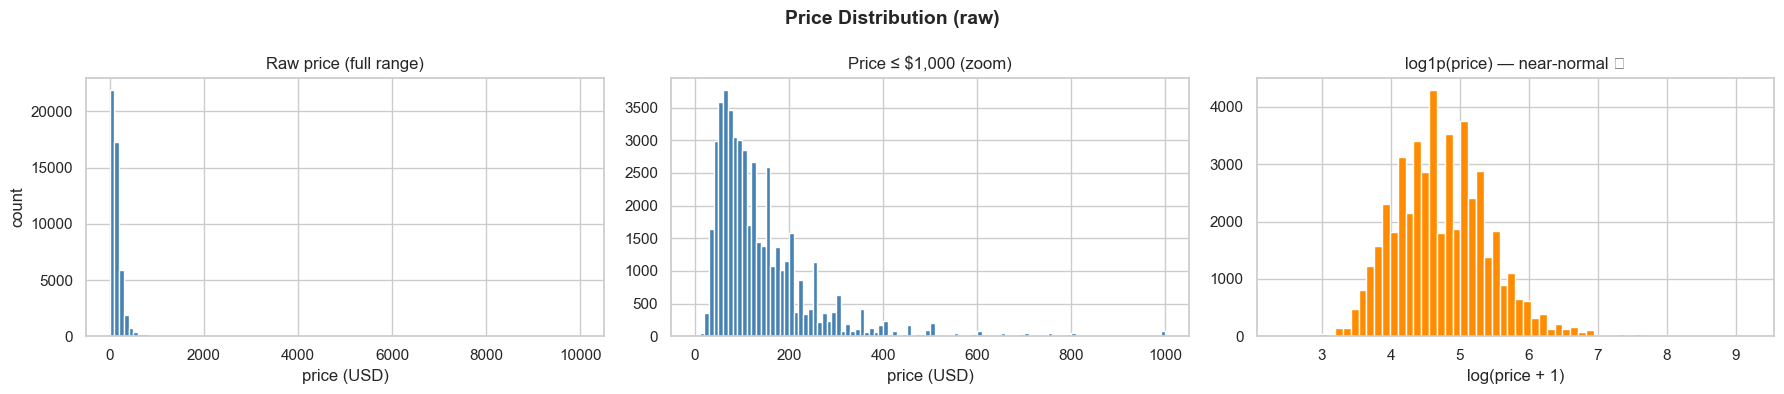

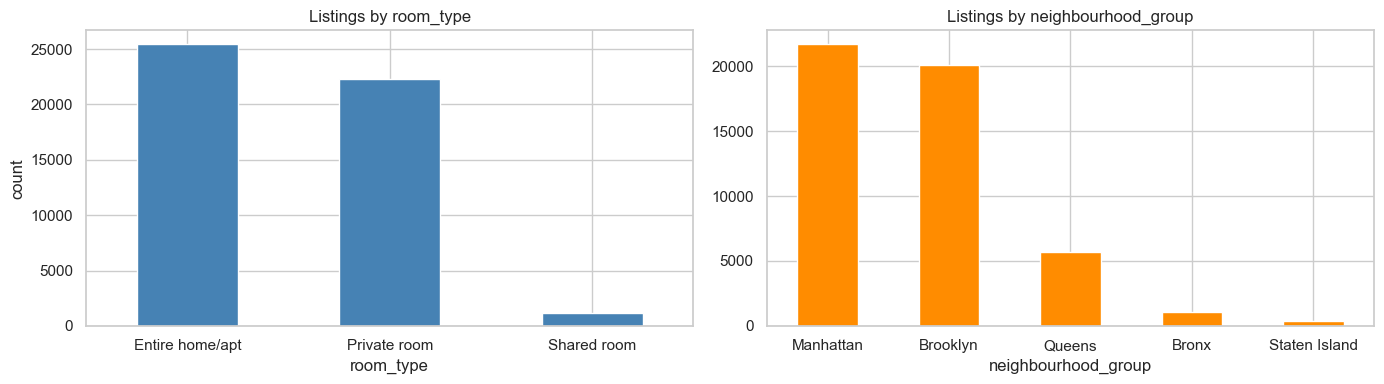

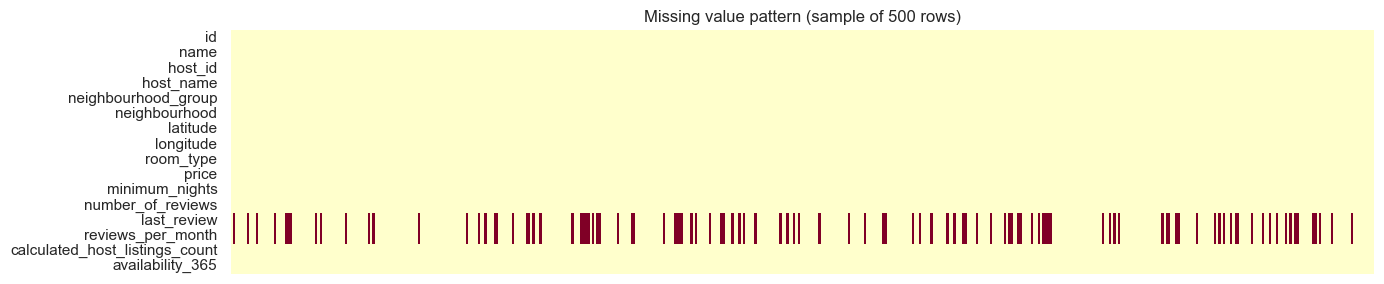

In [18]:
# ── 2.1  EDA ────────────────────────────────────────────────────────────────
# Run the structural inspector from Step 1 first
inspect_dataframe(df_raw)

# ── Price distribution ───────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 4))
fig.suptitle("Price Distribution (raw)", fontsize=14, fontweight="bold")

# Raw price — shows heavy right skew and extreme outliers
axes[0].hist(df_raw["price"], bins=100, color="steelblue", edgecolor="white")
axes[0].set_title("Raw price (full range)")
axes[0].set_xlabel("price (USD)")
axes[0].set_ylabel("count")

# Zoomed to ≤ $1,000 — covers ~99% of listings
axes[1].hist(df_raw[df_raw["price"] <= 1000]["price"], bins=100, color="steelblue", edgecolor="white")
axes[1].set_title("Price ≤ $1,000 (zoom)")
axes[1].set_xlabel("price (USD)")

# Log-transformed price — note the near-normal shape → ideal ML target
axes[2].hist(np.log1p(df_raw[df_raw["price"] > 0]["price"]), bins=60, color="darkorange", edgecolor="white")
axes[2].set_title("log1p(price) — near-normal ✔")
axes[2].set_xlabel("log(price + 1)")

plt.tight_layout()
plt.show()

# ── Categorical feature counts ───────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

df_raw["room_type"].value_counts().plot(kind="bar", ax=axes[0], color="steelblue", rot=0)
axes[0].set_title("Listings by room_type")
axes[0].set_ylabel("count")

df_raw["neighbourhood_group"].value_counts().plot(kind="bar", ax=axes[1], color="darkorange", rot=0)
axes[1].set_title("Listings by neighbourhood_group")

plt.tight_layout()
plt.show()

# ── Missing values heatmap (sampled for speed) ───────────────────────────────
plt.figure(figsize=(14, 3))
sns.heatmap(
    df_raw.isnull().sample(n=min(500, len(df_raw)), random_state=42).T,
    cbar=False,
    yticklabels=True,
    xticklabels=False,
    cmap="YlOrRd",
)
plt.title("Missing value pattern (sample of 500 rows)")
plt.tight_layout()
plt.show()


In [22]:
def drop_useless_columns(df: pd.DataFrame) -> pd.DataFrame:
    """
    Remove columns that carry no predictive signal for price.

    Dropped columns and rationale
    ─────────────────────────────
    id, host_id          : arbitrary surrogate keys — no semantic meaning
    name, host_name      : free-text fields; NLP is out of scope for this
                           pipeline, and missing values are common
    last_review          : raw date string; we derive 'days_since_last_review'
                           in the feature engineering step instead

    Also removes listings where price == 0.  A $0 listing is either a data
    entry error or a blocked/unavailable night — it cannot serve as a valid
    training label for price prediction.

    Parameters
    ----------
    df : pd.DataFrame
        Raw DataFrame from S3.

    Returns
    -------
    pd.DataFrame
        DataFrame with irrelevant columns removed and invalid price rows filtered.
    """
    COLS_TO_DROP = ["id", "host_id", "name", "host_name"]

    df = df.drop(columns=COLS_TO_DROP, errors="ignore")

    before = len(df)
    df = df[df["price"] > 0].copy()
    removed = before - len(df)
    logger.info("drop_useless_columns: removed %d columns, filtered %d zero-price rows.", len(COLS_TO_DROP), removed)
    return df

In [23]:
def handle_missing_values(df: pd.DataFrame) -> pd.DataFrame:
    """
    Impute all missing values with domain-informed strategies.

    Column              Missing %   Strategy
    ──────────────────  ─────────   ──────────────────────────────────────────
    reviews_per_month   ~20 %       Fill with 0.  A listing with no reviews
                                    genuinely has 0 reviews per month; using
                                    the mean would inflate the feature for
                                    unlisted/new properties.
    last_review         ~20 %       Not filled here — converted to a numeric
                                    feature ('days_since_last_review') in the
                                    feature engineering step; NaN → sentinel.

    Parameters
    ----------
    df : pd.DataFrame

    Returns
    -------
    pd.DataFrame
    """
    df = df.copy()

    # reviews_per_month: NaN means the listing has never been reviewed
    filled = df["reviews_per_month"].isna().sum()
    df["reviews_per_month"] = df["reviews_per_month"].fillna(0.0)

    logger.info("handle_missing_values: filled %d NaNs in 'reviews_per_month' with 0.", filled)
    logger.info("Remaining nulls per column:\n%s", df.isnull().sum()[df.isnull().sum() > 0].to_string())
    return df

In [24]:
def cap_outliers(
    df: pd.DataFrame,
    columns: list[str],
    upper_percentile: float = 99.0,
) -> pd.DataFrame:
    """
    Cap extreme outliers by clipping column values at a given upper percentile.

    Why percentile capping instead of IQR removal?
    ───────────────────────────────────────────────
    Removing rows entirely would discard ~1 % of listings — a significant
    loss for a 48 k-row dataset.  Capping *preserves* every row while
    bounding the influence of extreme values on model training.  This is
    the standard approach in pricing models where legitimate high-value
    listings (luxury penthouses at $10,000/night) exist but should not
    dominate the regression.

    Columns capped and rationale
    ─────────────────────────────
    price          : Raw max is $10,000.  The 99th percentile (~$550) safely
                     includes high-end listings while removing data-entry errors.
    minimum_nights : Raw max is 1,250 nights — clearly erroneous for a nightly
                     pricing model.  The 99th percentile (~30 nights) is enough
                     to cover monthly stays.

    Parameters
    ----------
    df               : pd.DataFrame
    columns          : list of column names to cap
    upper_percentile : threshold percentile (default 99)

    Returns
    -------
    pd.DataFrame
    """
    df = df.copy()
    for col in columns:
        upper = np.percentile(df[col], upper_percentile)
        before_max = df[col].max()
        df[col] = df[col].clip(upper=upper)
        logger.info(
            "cap_outliers: '%s' → capped at p%.0f = %.2f  (was %.2f)",
            col, upper_percentile, upper, before_max,
        )
    return df

In [25]:
def engineer_features(df: pd.DataFrame, reference_date: str = "2019-07-08") -> pd.DataFrame:
    """
    Create new features from existing columns to improve model signal.

    New features
    ────────────
    log_price               : np.log1p(price)
                              The price distribution is heavily right-skewed.
                              Log-transforming the target makes it near-normal,
                              which significantly improves performance of linear
                              and tree-based models.  This column becomes the
                              model's training target; raw 'price' is retained
                              for interpretability.

    days_since_last_review  : (reference_date - last_review).days
                              Converts the raw date string into a numeric
                              feature that captures listing activity recency.
                              Listings with no reviews receive a sentinel of
                              max_value + 30 (signals 'never reviewed').

    has_reviews             : int  (0 / 1)
                              Binary flag for listings that have at least one
                              review.  Captures the cold-start effect: new
                              or inactive listings with no social proof often
                              command lower prices.

    reviews_per_minimum_night:  reviews_per_month / minimum_nights
                              Normalises review activity by the minimum stay
                              requirement, creating a density signal.

    Parameters
    ----------
    df             : pd.DataFrame  (after cleaning & outlier capping)
    reference_date : str  ISO date string used as 'today' for computing
                          days_since_last_review.  Defaults to the approximate
                          data collection date of the NYC 2019 dataset.

    Returns
    -------
    pd.DataFrame
    """
    df = df.copy()
    ref = pd.Timestamp(reference_date)

    # ── Log-transformed target ────────────────────────────────────────────────
    df["log_price"] = np.log1p(df["price"])

    # ── Review recency ────────────────────────────────────────────────────────
    last_review_dt = pd.to_datetime(df["last_review"], errors="coerce")
    days = (ref - last_review_dt).dt.days
    max_days = int(days.max(skipna=True))
    # Sentinel: listings never reviewed get max + 30 days
    df["days_since_last_review"] = days.fillna(max_days + 30).astype(int)
    df = df.drop(columns=["last_review"], errors="ignore")

    # ── Binary review flag ────────────────────────────────────────────────────
    df["has_reviews"] = (df["number_of_reviews"] > 0).astype(int)

    # ── Review density feature ────────────────────────────────────────────────
    df["reviews_per_min_night"] = (
        df["reviews_per_month"] / df["minimum_nights"].replace(0, 1)
    ).round(4)

    logger.info(
        "engineer_features: added log_price, days_since_last_review, "
        "has_reviews, reviews_per_min_night.  Shape: %s", df.shape
    )
    return df

In [26]:
def encode_categorical_features(df: pd.DataFrame) -> pd.DataFrame:
    """
    Encode categorical columns into numeric representations suitable for ML.

    Encoding decisions
    ──────────────────
    room_type (3 unique values)
        One-hot encoding.  Low cardinality; no ordinal relationship.
        Produces: room_type_Private room, room_type_Shared room
        (Entire home/apt is the drop-first baseline — avoids dummy-variable trap)

    neighbourhood_group (5 unique values)
        One-hot encoding.  Low cardinality; no ordinal relationship.
        (Bronx is the drop-first baseline)

    neighbourhood (221 unique values)
        Target-mean encoding: replace each neighbourhood with the mean
        log_price of all listings in that neighbourhood.
        Rationale: one-hot encoding would add 221 sparse columns, harming
        regularised models and bloating tree ensembles.  Target encoding
        distils location signal into a single dense numeric feature and is
        the standard approach in real-world pricing and real-estate models.
        ⚠ Computed on the full cleaned dataset here; in a production pipeline
        this mapping would be fitted on training data only to prevent leakage.

    Parameters
    ----------
    df : pd.DataFrame  (after feature engineering)

    Returns
    -------
    pd.DataFrame with all categorical columns replaced by numeric equivalents.
    """
    df = df.copy()

    # ── Target-mean encode neighbourhood ─────────────────────────────────────
    neighbourhood_price_map: dict[str, float] = (
        df.groupby("neighbourhood")["log_price"].mean().to_dict()
    )
    df["neighbourhood_encoded"] = df["neighbourhood"].map(neighbourhood_price_map)
    df = df.drop(columns=["neighbourhood"])

    # ── One-hot encode room_type and neighbourhood_group ─────────────────────
    df = pd.get_dummies(df, columns=["room_type", "neighbourhood_group"], drop_first=True)

    # Convert boolean dummy columns to int (0 / 1) for cleaner downstream use
    bool_cols = df.select_dtypes(include="bool").columns
    df[bool_cols] = df[bool_cols].astype(int)

    logger.info(
        "encode_categorical_features: final shape %s  |  columns: %s",
        df.shape,
        df.columns.tolist(),
    )
    return df, neighbourhood_price_map

2026-04-03 22:32:16  INFO      ============================================================
2026-04-03 22:32:16  INFO      Starting preprocessing pipeline …
2026-04-03 22:32:16  INFO      Input shape: (48895, 16)
2026-04-03 22:32:16  INFO      drop_useless_columns: removed 4 columns, filtered 11 zero-price rows.
2026-04-03 22:32:16  INFO      handle_missing_values: filled 10051 NaNs in 'reviews_per_month' with 0.
2026-04-03 22:32:16  INFO      Remaining nulls per column:
last_review    10051
2026-04-03 22:32:16  INFO      cap_outliers: 'price' → capped at p99 = 799.00  (was 10000.00)
2026-04-03 22:32:16  INFO      cap_outliers: 'minimum_nights' → capped at p99 = 45.00  (was 1250.00)
2026-04-03 22:32:16  INFO      engineer_features: added log_price, days_since_last_review, has_reviews, reviews_per_min_night.  Shape: (48884, 15)
2026-04-03 22:32:16  INFO      encode_categorical_features: final shape (48884, 19)  |  columns: ['latitude', 'longitude', 'price', 'minimum_nights', 'number_of_


Sample rows:


,latitude,longitude,price,minimum_nights,number_of_reviews,reviews_per_month,calculated_host_listings_count,availability_365,log_price,days_since_last_review,has_reviews,reviews_per_min_night,neighbourhood_encoded,room_type_Private room,room_type_Shared room,neighbourhood_group_Brooklyn,neighbourhood_group_Manhattan,neighbourhood_group_Queens,neighbourhood_group_Staten Island
0,40.64749,-73.97237,149,1,9,0.21,6,365,5.010635,262,1,0.21,4.347619,1,0,1,0,0,0
1,40.75362,-73.98377,225,1,45,0.38,2,355,5.420535,48,1,0.38,5.412092,0,0,0,1,0,0
2,40.80902,-73.94190,150,3,0,0.00,1,365,5.017280,3054,0,0.00,4.568495,1,0,0,1,0,0
3,40.68514,-73.95976,89,1,270,4.64,1,194,4.499810,3,1,4.64,4.815556,0,0,1,0,0,0
4,40.79851,-73.94399,80,10,9,0.10,1,0,4.394449,231,1,0.01,4.655017,0,0,0,1,0,0



Data types:
latitude                             float64
longitude                            float64
price                                  int64
minimum_nights                         int64
number_of_reviews                      int64
reviews_per_month                    float64
calculated_host_listings_count         int64
availability_365                       int64
log_price                            float64
days_since_last_review                 int64
has_reviews                            int64
reviews_per_min_night                float64
neighbourhood_encoded                float64
room_type_Private room                 int64
room_type_Shared room                  int64
neighbourhood_group_Brooklyn           int64
neighbourhood_group_Manhattan          int64
neighbourhood_group_Queens             int64
neighbourhood_group_Staten Island      int64

Missing values: 0 total

Target (log_price) distribution:
count    48884.0000
mean         4.7327
std          0.6724
min          

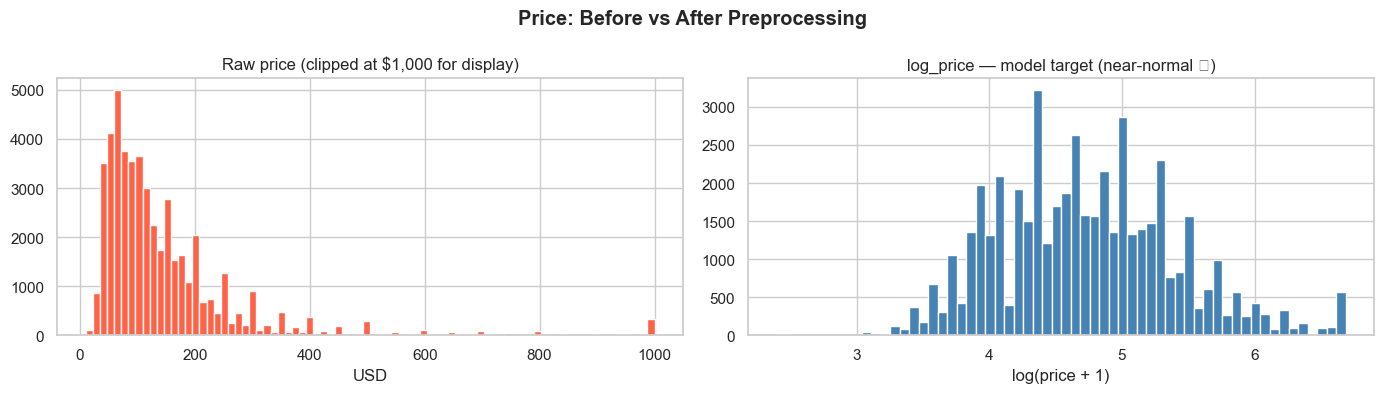


Final feature columns (19):
  latitude
  longitude
  price
  minimum_nights
  number_of_reviews
  reviews_per_month
  calculated_host_listings_count
  availability_365
  log_price
  days_since_last_review
  has_reviews
  reviews_per_min_night
  neighbourhood_encoded
  room_type_Private room
  room_type_Shared room
  neighbourhood_group_Brooklyn
  neighbourhood_group_Manhattan
  neighbourhood_group_Queens
  neighbourhood_group_Staten Island


In [27]:
# ── Run the full preprocessing pipeline ──────────────────────────────────────
logger.info("=" * 60)
logger.info("Starting preprocessing pipeline …")
logger.info("Input shape: %s", df_raw.shape)

df_clean = drop_useless_columns(df_raw)
df_clean = handle_missing_values(df_clean)
df_clean = cap_outliers(df_clean, columns=["price", "minimum_nights"], upper_percentile=99)
df_clean = engineer_features(df_clean)
df_clean, neighbourhood_price_map = encode_categorical_features(df_clean)

logger.info("Pipeline complete.  Final shape: %s", df_clean.shape)
logger.info("=" * 60)

# ── Final dataset inspection ──────────────────────────────────────────────────
print("\nSample rows:")
display(df_clean.head())

print("\nData types:")
print(df_clean.dtypes.to_string())

print(f"\nMissing values: {df_clean.isnull().sum().sum()} total")

print("\nTarget (log_price) distribution:")
print(df_clean["log_price"].describe().round(4).to_string())

# Compare pre/post price distributions
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
fig.suptitle("Price: Before vs After Preprocessing", fontweight="bold")

axes[0].hist(df_raw[df_raw["price"] > 0]["price"].clip(upper=1000), bins=80, color="tomato", edgecolor="white")
axes[0].set_title("Raw price (clipped at $1,000 for display)")
axes[0].set_xlabel("USD")

axes[1].hist(df_clean["log_price"], bins=60, color="steelblue", edgecolor="white")
axes[1].set_title("log_price — model target (near-normal ✔)")
axes[1].set_xlabel("log(price + 1)")

plt.tight_layout()
plt.show()

print(f"\nFinal feature columns ({len(df_clean.columns)}):")
for col in df_clean.columns:
    print(f"  {col}")

---
## Step 3 — Model Development & Comparison

**Goal:** Train multiple regression models on the clean feature matrix from Step 2, evaluate each one rigorously, and identify the best candidate for productionisation in Step 4 (MLflow tracking).

### Models compared
| Model | Type | Why included |
|-------|------|-------------|
| **Linear Regression** | Linear baseline | Establishes a lower-bound; interpretable coefficients |
| **Ridge Regression** | Regularised linear | Handles multicollinearity from one-hot features; L2 penalty shrinks coefficients |
| **Lasso Regression** | Regularised linear | L1 penalty performs implicit feature selection — informative for high-dim pipelines |
| **Random Forest** | Ensemble (bagging) | Non-linear, robust to outliers and scale, built-in feature importance |
| **Gradient Boosting** | Ensemble (boosting) | State-of-the-art for tabular regression; captures complex interactions |

### Evaluation strategy
- **Target**: `log_price` (near-normal after Step 2 transformation)  
- **Metrics reported in log-space**: RMSE, MAE, R²  
- **Metric reported in original price space**: RMSE ($) — obtained by back-transforming predictions with `np.expm1()`, making the error interpretable to business stakeholders  
- **5-fold cross-validation** on the training set for unbiased metric estimation  
- **Hold-out test set** (20%) for final model comparison

In [44]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# ── Define feature matrix X and target vector y ──────────────────────────────
# Exclude raw 'price' from features — it is the un-transformed version of our
# target and would constitute perfect data leakage.
# log_price is the target; all remaining columns are features.
TARGET: str = "log_price"
LEAKAGE_COLS: list[str] = ["price"]   # raw price — derived from the target

# ── Features dropped for this experiment ─────────────────────────────────────
# The four neighbourhood_group one-hot columns are excluded to test whether
# the model improves without them.  Rationale: 'neighbourhood_encoded'
# (target-mean encoding) already captures location signal at a finer grain
# (221 neighbourhoods vs 5 groups), making the broader borough dummies
# potentially redundant.  Dropping them reduces dimensionality and may reduce
# noise for linear models.
DROPPED_FEATURES: list[str] = [
    "neighbourhood_group_Brooklyn",
    "neighbourhood_group_Manhattan",
    "neighbourhood_group_Queens",
    "neighbourhood_group_Staten Island",
]

FEATURE_COLS: list[str] = [
    c for c in df_clean.columns
    if c not in [TARGET] + LEAKAGE_COLS + DROPPED_FEATURES
]

X = df_clean[FEATURE_COLS].values
y = df_clean[TARGET].values

logger.info("Feature matrix X : %s", X.shape)
logger.info("Target vector y  : %s  (log_price)", y.shape)
logger.info("Dropped features : %s", DROPPED_FEATURES)
logger.info("Features used    : %s", FEATURE_COLS)

# ── Train / test split (80 / 20) ─────────────────────────────────────────────
# random_state=42 ensures reproducibility across all runs (SDLC: repeatability)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42
)

logger.info("Train size : %d rows", len(X_train))
logger.info("Test size  : %d rows", len(X_test))

# ── Feature scaling ───────────────────────────────────────────────────────────
# Required by linear models (Ridge, Lasso, LinearRegression): unscaled features
# with vastly different ranges (e.g. latitude ~40 vs availability_365 ~0–365)
# bias coefficient magnitudes and slow convergence.
# Tree-based models (RF, GBM) are scale-invariant but scaling does no harm.
# Scaler is fitted on train-only to avoid data leakage into the test set.
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

logger.info("StandardScaler fitted on training set only (no leakage).")

2026-04-03 23:26:23  INFO      Feature matrix X : (48884, 13)
2026-04-03 23:26:23  INFO      Target vector y  : (48884,)  (log_price)
2026-04-03 23:26:23  INFO      Dropped features : ['neighbourhood_group_Brooklyn', 'neighbourhood_group_Manhattan', 'neighbourhood_group_Queens', 'neighbourhood_group_Staten Island']
2026-04-03 23:26:23  INFO      Features used    : ['latitude', 'longitude', 'minimum_nights', 'number_of_reviews', 'reviews_per_month', 'calculated_host_listings_count', 'availability_365', 'days_since_last_review', 'has_reviews', 'reviews_per_min_night', 'neighbourhood_encoded', 'room_type_Private room', 'room_type_Shared room']
2026-04-03 23:26:23  INFO      Train size : 39107 rows
2026-04-03 23:26:23  INFO      Test size  : 9777 rows
2026-04-03 23:26:23  INFO      StandardScaler fitted on training set only (no leakage).


In [45]:
from sklearn.ensemble import GradientBoostingRegressor, RandomForestRegressor
from sklearn.linear_model import Lasso, LinearRegression, Ridge

# ── Model registry ────────────────────────────────────────────────────────────
# Each entry is a (name, model_instance, uses_scaled_input) tuple.
#
# uses_scaled_input:
#   True  → linear models that need StandardScaler output
#   False → tree-based models that are scale-invariant
#
# Hyperparameters are deliberately kept simple here.
# Step 4 (MLflow) will log these params; grid search / tuning is a natural
# next step once the tracking infrastructure is in place.
MODELS: list[tuple[str, object, bool]] = [
    (
        "Linear Regression",
        LinearRegression(),
        True,
    ),
    (
        "Ridge (α=1.0)",
        Ridge(alpha=1.0, random_state=42),
        True,
    ),
    (
        "Lasso (α=0.01)",
        # α=0.01 chosen so Lasso stays competitive but still zeros some weights.
        # α=1.0 (default) over-penalises log_price scale and collapses to near-zero.
        Lasso(alpha=0.01, max_iter=5000, random_state=42),
        True,
    ),
    (
        "Random Forest",
        RandomForestRegressor(
            n_estimators=200,
            max_depth=20,
            min_samples_leaf=4,
            n_jobs=-1,
            random_state=42,
        ),
        False,
    ),
    (
        "Gradient Boosting",
        GradientBoostingRegressor(
            n_estimators=300,
            learning_rate=0.05,
            max_depth=5,
            subsample=0.8,
            random_state=42,
        ),
        False,
    ),
]

logger.info("Model registry: %d models defined.", len(MODELS))
for name, _, scaled in MODELS:
    logger.info("  %-25s  scaled_input=%s", name, scaled)

2026-04-03 23:26:29  INFO      Model registry: 5 models defined.
2026-04-03 23:26:29  INFO        Linear Regression          scaled_input=True
2026-04-03 23:26:29  INFO        Ridge (α=1.0)              scaled_input=True
2026-04-03 23:26:29  INFO        Lasso (α=0.01)             scaled_input=True
2026-04-03 23:26:29  INFO        Random Forest              scaled_input=False
2026-04-03 23:26:29  INFO        Gradient Boosting          scaled_input=False


In [46]:
import time
from typing import Any

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import KFold, cross_val_score


def evaluate_on_split(
    model: Any,
    X_tr: np.ndarray,
    y_tr: np.ndarray,
    X_te: np.ndarray,
    y_te: np.ndarray,
) -> dict[str, float]:
    """
    Fit a model on the training split and compute metrics on the test split.

    All primary metrics are computed in log-space (the model's native space).
    RMSE in original price ($) is computed by back-transforming predictions
    with np.expm1() — the inverse of the np.log1p() applied in Step 2.

    Parameters
    ----------
    model        : sklearn estimator (not yet fitted)
    X_tr, y_tr   : training features and log-price target
    X_te, y_te   : test features and log-price target

    Returns
    -------
    dict with keys: rmse_log, mae_log, r2, rmse_usd, train_time_s
    """
    t0 = time.perf_counter()
    model.fit(X_tr, y_tr)
    train_time = time.perf_counter() - t0

    y_pred_log = model.predict(X_te)

    rmse_log = np.sqrt(mean_squared_error(y_te, y_pred_log))
    mae_log  = mean_absolute_error(y_te, y_pred_log)
    r2       = r2_score(y_te, y_pred_log)

    # Back-transform to original price scale for business interpretation
    rmse_usd = np.sqrt(mean_squared_error(np.expm1(y_te), np.expm1(y_pred_log)))

    return {
        "rmse_log":     round(rmse_log, 4),
        "mae_log":      round(mae_log, 4),
        "r2":           round(r2, 4),
        "rmse_usd":     round(rmse_usd, 2),
        "train_time_s": round(train_time, 2),
    }


def cross_validate_model(
    model: Any,
    X_tr: np.ndarray,
    y_tr: np.ndarray,
    cv_folds: int = 5,
) -> dict[str, float]:
    """
    Run k-fold cross-validation and return mean ± std of RMSE and R².

    5-fold CV gives 5 estimates on different data subsets — the mean is a
    more reliable generalisation signal than a single train/test split,
    and the std reveals model variance (high std → unstable model).

    Parameters
    ----------
    model    : sklearn estimator
    X_tr     : scaled or raw training features
    y_tr     : log-price training target
    cv_folds : number of folds (default 5)

    Returns
    -------
    dict with keys: cv_rmse_mean, cv_rmse_std, cv_r2_mean, cv_r2_std
    """
    kf = KFold(n_splits=cv_folds, shuffle=True, random_state=42)

    neg_mse_scores = cross_val_score(model, X_tr, y_tr, cv=kf, scoring="neg_mean_squared_error", n_jobs=-1)
    r2_scores      = cross_val_score(model, X_tr, y_tr, cv=kf, scoring="r2",                    n_jobs=-1)

    rmse_scores = np.sqrt(-neg_mse_scores)

    return {
        "cv_rmse_mean": round(rmse_scores.mean(), 4),
        "cv_rmse_std":  round(rmse_scores.std(),  4),
        "cv_r2_mean":   round(r2_scores.mean(),   4),
        "cv_r2_std":    round(r2_scores.std(),     4),
    }


logger.info("Evaluation functions defined.")

2026-04-03 23:26:35  INFO      Evaluation functions defined.


In [48]:
# ── Train and evaluate all models ─────────────────────────────────────────────
# Results are collected in a list of dicts, then converted to a DataFrame
# so they can be displayed as a sorted leaderboard table.
# Trained model objects are stored in `trained_models` for Step 4 (MLflow).

results: list[dict] = []
trained_models: dict[str, Any] = {}

for model_name, model, use_scaled in MODELS:
    logger.info("Training: %s …", model_name)

    X_tr = X_train_scaled if use_scaled else X_train
    X_te = X_test_scaled  if use_scaled else X_test

    # ── 5-fold cross-validation on training set ───────────────────────────────
    cv_metrics = cross_validate_model(model, X_tr, y_train, cv_folds=5)

    # ── Final fit on full training set + hold-out test evaluation ─────────────
    test_metrics = evaluate_on_split(model, X_tr, y_train, X_te, y_test)

    # Store fitted model for later use
    trained_models[model_name] = model

    row = {"model": model_name, **cv_metrics, **test_metrics}
    results.append(row)

    logger.info(
        "  CV RMSE (log): %.4f ± %.4f  |  Test R²: %.4f  |  Test RMSE ($): $%.2f",
        cv_metrics["cv_rmse_mean"], cv_metrics["cv_rmse_std"],
        test_metrics["r2"], test_metrics["rmse_usd"],
    )

logger.info("All models trained and evaluated.")

2026-04-03 23:26:47  INFO      Training: Linear Regression …
2026-04-03 23:26:51  INFO        CV RMSE (log): 0.4357 ± 0.0049  |  Test R²: 0.5635  |  Test RMSE ($): $99.73
2026-04-03 23:26:51  INFO      Training: Ridge (α=1.0) …
2026-04-03 23:26:55  INFO        CV RMSE (log): 0.4357 ± 0.0049  |  Test R²: 0.5635  |  Test RMSE ($): $99.73
2026-04-03 23:26:55  INFO      Training: Lasso (α=0.01) …
2026-04-03 23:26:56  INFO        CV RMSE (log): 0.4372 ± 0.0049  |  Test R²: 0.5613  |  Test RMSE ($): $100.61
2026-04-03 23:26:56  INFO      Training: Random Forest …
2026-04-03 23:27:10  INFO        CV RMSE (log): 0.4082 ± 0.0049  |  Test R²: 0.6216  |  Test RMSE ($): $93.09
2026-04-03 23:27:10  INFO      Training: Gradient Boosting …
2026-04-03 23:27:53  INFO        CV RMSE (log): 0.4077 ± 0.0049  |  Test R²: 0.6178  |  Test RMSE ($): $94.79
2026-04-03 23:27:53  INFO      All models trained and evaluated.



MODEL LEADERBOARD — sorted by Test R² (descending)


,CV RMSE (log) mean,CV RMSE (log) std,CV R² mean,Test RMSE (log),Test MAE (log),Test R²,Test RMSE ($),Train time (s)
model,,,,,,,,
Random Forest,0.4082,0.0049,0.6307,0.4153,0.3032,0.6216,93.09,1.65
Gradient Boosting,0.4077,0.0049,0.6316,0.4174,0.3072,0.6178,94.79,16.42
Linear Regression,0.4357,0.0049,0.5792,0.4461,0.3319,0.5635,99.73,0.01
Ridge (α=1.0),0.4357,0.0049,0.5792,0.4461,0.3319,0.5635,99.73,0.00
Lasso (α=0.01),0.4372,0.0049,0.5762,0.4472,0.3319,0.5613,100.61,0.04


2026-04-03 23:28:00  INFO      Best model: 'Random Forest'  (Test R² = 0.6216, Test RMSE = $93.09)


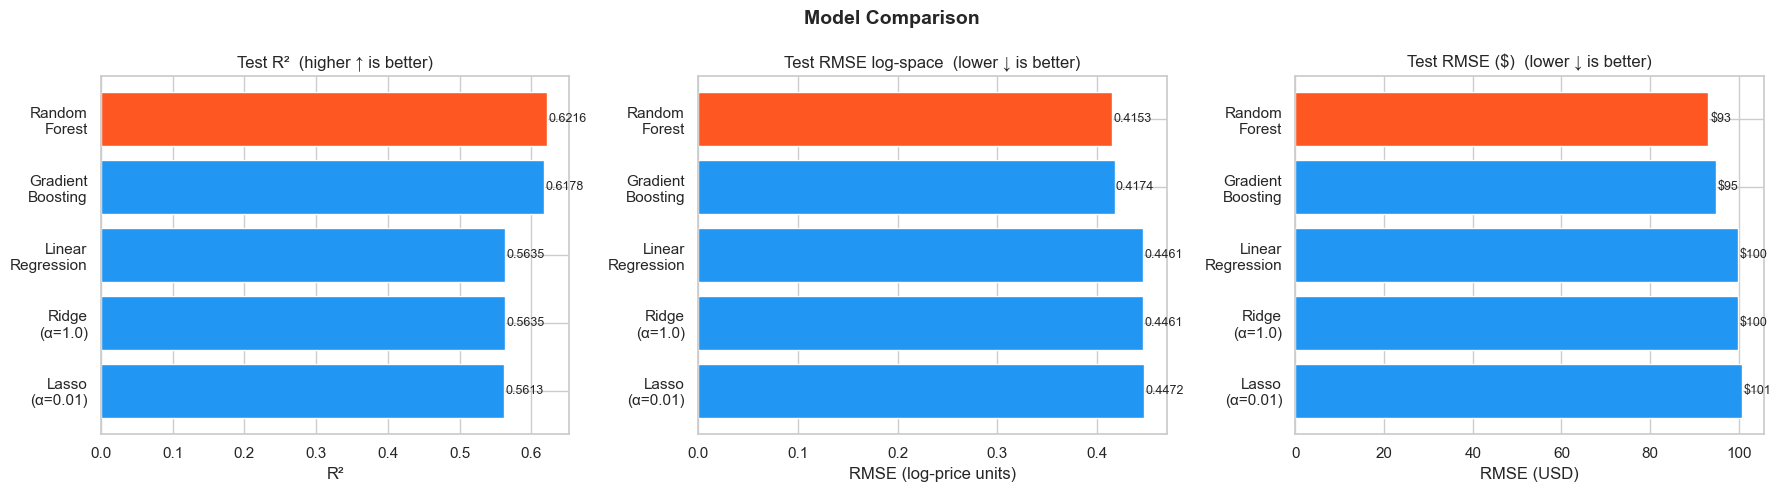

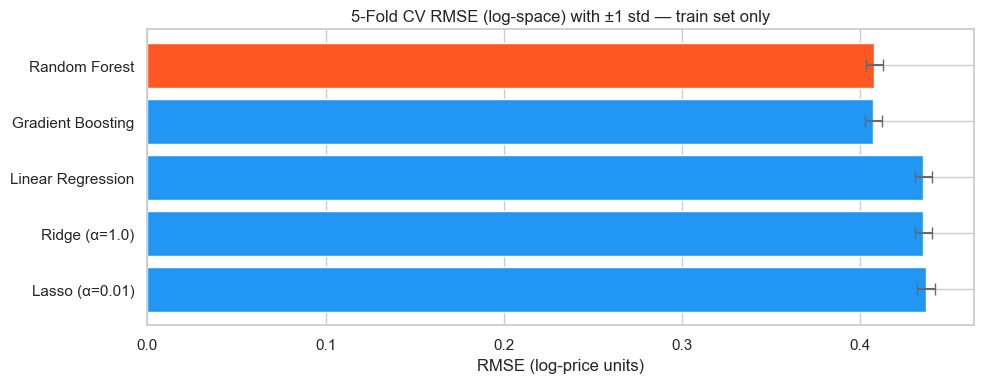

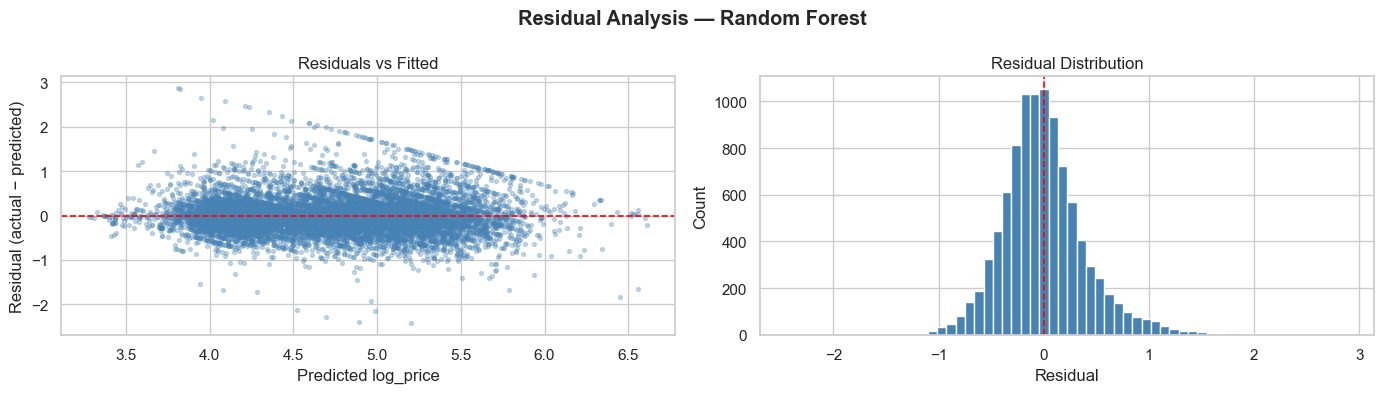

In [49]:
# ── Leaderboard table ─────────────────────────────────────────────────────────
df_results = pd.DataFrame(results).set_index("model")

# Sort by test R² descending (best model first)
df_results = df_results.sort_values("r2", ascending=False)

DISPLAY_COLS = {
    "cv_rmse_mean":  "CV RMSE (log) mean",
    "cv_rmse_std":   "CV RMSE (log) std",
    "cv_r2_mean":    "CV R² mean",
    "rmse_log":      "Test RMSE (log)",
    "mae_log":       "Test MAE (log)",
    "r2":            "Test R²",
    "rmse_usd":      "Test RMSE ($)",
    "train_time_s":  "Train time (s)",
}
print("\n" + "=" * 70)
print("MODEL LEADERBOARD — sorted by Test R² (descending)")
print("=" * 70)
display(df_results[list(DISPLAY_COLS.keys())].rename(columns=DISPLAY_COLS))

# Identify the best model by test R²
best_model_name: str = df_results.index[0]
best_model = trained_models[best_model_name]
logger.info("Best model: '%s'  (Test R² = %.4f, Test RMSE = $%.2f)",
            best_model_name,
            df_results.loc[best_model_name, "r2"],
            df_results.loc[best_model_name, "rmse_usd"])

# ── Comparison bar charts ─────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle("Model Comparison", fontsize=14, fontweight="bold")

colors = ["#2196F3" if n != best_model_name else "#FF5722"
          for n in df_results.index]
short_names = [n.split(" ")[0] + ("\n" + n.split(" ")[1] if len(n.split(" ")) > 1 else "")
               for n in df_results.index]

# R² (higher is better)
axes[0].barh(short_names, df_results["r2"], color=colors, edgecolor="white")
axes[0].set_title("Test R²  (higher ↑ is better)")
axes[0].set_xlabel("R²")
axes[0].invert_yaxis()
for bar, val in zip(axes[0].patches, df_results["r2"]):
    axes[0].text(bar.get_width() + 0.002, bar.get_y() + bar.get_height() / 2,
                 f"{val:.4f}", va="center", fontsize=9)

# Test RMSE log-space (lower is better)
axes[1].barh(short_names, df_results["rmse_log"], color=colors, edgecolor="white")
axes[1].set_title("Test RMSE log-space  (lower ↓ is better)")
axes[1].set_xlabel("RMSE (log-price units)")
axes[1].invert_yaxis()
for bar, val in zip(axes[1].patches, df_results["rmse_log"]):
    axes[1].text(bar.get_width() + 0.001, bar.get_y() + bar.get_height() / 2,
                 f"{val:.4f}", va="center", fontsize=9)

# Test RMSE in USD (lower is better — most interpretable for stakeholders)
axes[2].barh(short_names, df_results["rmse_usd"], color=colors, edgecolor="white")
axes[2].set_title("Test RMSE ($)  (lower ↓ is better)")
axes[2].set_xlabel("RMSE (USD)")
axes[2].invert_yaxis()
for bar, val in zip(axes[2].patches, df_results["rmse_usd"]):
    axes[2].text(bar.get_width() + 0.5, bar.get_y() + bar.get_height() / 2,
                 f"${val:.0f}", va="center", fontsize=9)

plt.tight_layout()
plt.show()

# ── CV RMSE with error bars ───────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 4))
ax.barh(
    df_results.index,
    df_results["cv_rmse_mean"],
    xerr=df_results["cv_rmse_std"],
    color=colors,
    edgecolor="white",
    capsize=4,
    error_kw={"elinewidth": 1.5, "ecolor": "dimgray"},
)
ax.set_title("5-Fold CV RMSE (log-space) with ±1 std — train set only")
ax.set_xlabel("RMSE (log-price units)")
ax.invert_yaxis()
plt.tight_layout()
plt.show()

# ── Residual plots for the best model ────────────────────────────────────────
best_use_scaled = next(s for n, _, s in MODELS if n == best_model_name)
X_te_best = X_test_scaled if best_use_scaled else X_test
y_pred_best = best_model.predict(X_te_best)
residuals   = y_test - y_pred_best

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
fig.suptitle(f"Residual Analysis — {best_model_name}", fontweight="bold")

axes[0].scatter(y_pred_best, residuals, alpha=0.3, s=8, color="steelblue")
axes[0].axhline(0, color="red", linewidth=1.2, linestyle="--")
axes[0].set_xlabel("Predicted log_price")
axes[0].set_ylabel("Residual (actual − predicted)")
axes[0].set_title("Residuals vs Fitted")

axes[1].hist(residuals, bins=60, color="steelblue", edgecolor="white")
axes[1].axvline(0, color="red", linewidth=1.2, linestyle="--")
axes[1].set_xlabel("Residual")
axes[1].set_ylabel("Count")
axes[1].set_title("Residual Distribution")

plt.tight_layout()
plt.show()

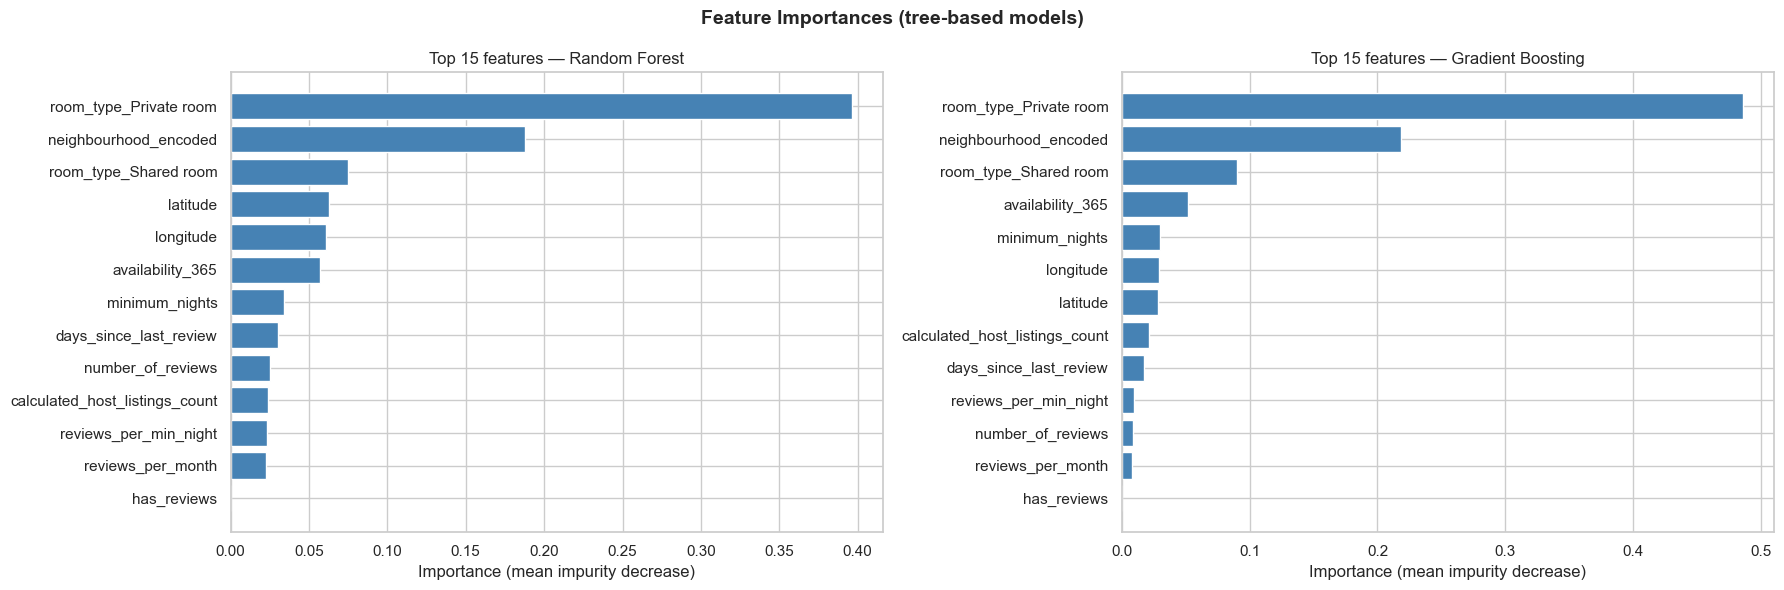


Lasso zeroed 3/13 features (automatic selection)

Non-zero Lasso |coefficients|:
room_type_Private room    0.338939
neighbourhood_encoded     0.252089
room_type_Shared room     0.152502
availability_365          0.091721
minimum_nights            0.080292
has_reviews               0.040537
latitude                  0.012283
reviews_per_min_night     0.009786
number_of_reviews         0.009548
longitude                 0.009114

STEP 3 SUMMARY
  Best model   : Random Forest
  Test R²      : 0.6216
  Test RMSE $  : $93.09

  → 'Random Forest' will be logged to MLflow in Step 4.


In [50]:
# ── Feature importance — tree-based models ────────────────────────────────────
# Both Random Forest and Gradient Boosting expose feature_importances_
# (mean impurity decrease across all trees).
# Linear models expose coef_ — we use |coefficient| as a proxy for importance.

def plot_feature_importance(
    model: Any,
    model_name: str,
    feature_names: list[str],
    top_n: int = 15,
    ax: plt.Axes = None,
) -> None:
    """Plot top-N feature importances for a fitted sklearn model."""
    if hasattr(model, "feature_importances_"):
        importances = model.feature_importances_
        importance_label = "Importance (mean impurity decrease)"
    elif hasattr(model, "coef_"):
        importances = np.abs(model.coef_)
        importance_label = "|Coefficient| (scaled features)"
    else:
        logger.warning("'%s' has no feature_importances_ or coef_.", model_name)
        return

    idx = np.argsort(importances)[::-1][:top_n]
    top_features = [feature_names[i] for i in idx]
    top_values   = importances[idx]

    if ax is None:
        _, ax = plt.subplots(figsize=(10, 6))

    ax.barh(top_features[::-1], top_values[::-1], color="steelblue", edgecolor="white")
    ax.set_title(f"Top {top_n} features — {model_name}")
    ax.set_xlabel(importance_label)


# ── Plot for tree-based models ────────────────────────────────────────────────
tree_models = [(n, m) for n, m, _ in MODELS if hasattr(m, "feature_importances_")]

fig, axes = plt.subplots(1, len(tree_models), figsize=(9 * len(tree_models), 6))
if len(tree_models) == 1:
    axes = [axes]

for ax, (name, model) in zip(axes, tree_models):
    plot_feature_importance(model, name, FEATURE_COLS, top_n=15, ax=ax)

plt.suptitle("Feature Importances (tree-based models)", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

# ── Lasso coefficient — shows automatic feature selection ────────────────────
lasso_model = trained_models["Lasso (α=0.01)"]
lasso_coef  = pd.Series(np.abs(lasso_model.coef_), index=FEATURE_COLS)
zeroed = (lasso_coef == 0).sum()
print(f"\nLasso zeroed {zeroed}/{len(FEATURE_COLS)} features (automatic selection)")
lasso_coef_nonzero = lasso_coef[lasso_coef > 0].sort_values(ascending=False)
print("\nNon-zero Lasso |coefficients|:")
print(lasso_coef_nonzero.to_string())

# ── Step 3 summary ────────────────────────────────────────────────────────────
print("\n" + "=" * 70)
print("STEP 3 SUMMARY")
print("=" * 70)
print(f"  Best model   : {best_model_name}")
print(f"  Test R²      : {df_results.loc[best_model_name, 'r2']:.4f}")
print(f"  Test RMSE $  : ${df_results.loc[best_model_name, 'rmse_usd']:.2f}")
print(f"\n  → '{best_model_name}' will be logged to MLflow in Step 4.")

---
## Step 4 — MLflow Experiment Tracking & Model Registry

**Goal:** Log every training run to MLflow so results are reproducible, queryable, and shareable. Then register the best model in the MLflow Model Registry for production use.

### What gets logged per run
| Artifact | Details |
|----------|---------|
| **Parameters** | Model hyperparameters, feature count, dropped features, scaling flag, split sizes |
| **Metrics** | CV RMSE mean/std, CV R², Test RMSE (log), Test MAE (log), Test R², Test RMSE ($), train time |
| **Model** | Fitted sklearn estimator via `mlflow.sklearn.log_model()` — includes `MLmodel` spec and `conda.yaml` |
| **Preprocessing** | `StandardScaler` pickle, `neighbourhood_price_map` JSON, `feature_config` JSON |
| **Plots** | Feature importance chart (tree-based models) |

### MLflow tracking hierarchy
```
Experiment: airbnb-price-prediction
  ├── Run: Linear Regression
  ├── Run: Ridge (α=1.0)
  ├── Run: Lasso (α=0.01)
  ├── Run: Random Forest      ← likely best
  └── Run: Gradient Boosting  ← likely best
```

After all runs are logged, the experiment is queried with `mlflow.search_runs()`, and the top model (highest `test_r2`) is registered in the **MLflow Model Registry** under the name `airbnb-price-predictor`.

In [51]:
import json
import os
import pickle
import tempfile

import mlflow
import mlflow.sklearn

# ── Experiment configuration ──────────────────────────────────────────────────
EXPERIMENT_NAME: str       = "airbnb-price-prediction"
REGISTERED_MODEL_NAME: str = "airbnb-price-predictor"

mlflow.set_experiment(EXPERIMENT_NAME)
logger.info("MLflow experiment : '%s'", EXPERIMENT_NAME)
logger.info("MLflow tracking URI: %s", mlflow.get_tracking_uri())


# ── Helpers: persist preprocessing artefacts to temp files ───────────────────
def _save_json(obj: dict, fname: str) -> str:
    """Serialise a Python dict to a temp JSON file and return the path."""
    path = os.path.join(tempfile.gettempdir(), fname)
    with open(path, "w") as fh:
        json.dump(obj, fh, indent=2)
    return path


def _save_pickle(obj, fname: str) -> str:
    """Pickle an object to a temp file and return the path."""
    path = os.path.join(tempfile.gettempdir(), fname)
    with open(path, "wb") as fh:
        pickle.dump(obj, fh)
    return path


# ── Log all trained models to MLflow ─────────────────────────────────────────
# run_ids is populated here and used in the registry cell below.
run_ids: dict[str, str] = {}

# Persist shared preprocessing artefacts once (same for all runs)
scaler_path  = _save_pickle(scaler, "scaler.pkl")
map_path     = _save_json(neighbourhood_price_map, "neighbourhood_price_map.json")
feat_path    = _save_json(
    {"feature_cols": FEATURE_COLS, "dropped_features": DROPPED_FEATURES},
    "feature_config.json",
)

for model_name, model, use_scaled in MODELS:
    logger.info("Logging '%s' to MLflow …", model_name)

    with mlflow.start_run(run_name=model_name) as run:

        # ── Parameters ────────────────────────────────────────────────────────
        mlflow.log_params(model.get_params())
        mlflow.log_param("n_features",       len(FEATURE_COLS))
        mlflow.log_param("use_scaled_input", use_scaled)
        mlflow.log_param("target",           TARGET)
        mlflow.log_param("dropped_features",
                         ", ".join(DROPPED_FEATURES) if DROPPED_FEATURES else "none")
        mlflow.log_param("train_rows",       len(X_train))
        mlflow.log_param("test_rows",        len(X_test))

        # ── Metrics (pre-computed in Step 3) ──────────────────────────────────
        row = df_results.loc[model_name]
        mlflow.log_metrics({
            "cv_rmse_mean":  float(row["cv_rmse_mean"]),
            "cv_rmse_std":   float(row["cv_rmse_std"]),
            "cv_r2_mean":    float(row["cv_r2_mean"]),
            "test_rmse_log": float(row["rmse_log"]),
            "test_mae_log":  float(row["mae_log"]),
            "test_r2":       float(row["r2"]),
            "test_rmse_usd": float(row["rmse_usd"]),
            "train_time_s":  float(row["train_time_s"]),
        })

        # ── Model artifact ────────────────────────────────────────────────────
        # input_example provides a sample row so MLflow can infer the input schema
        sample_input = (X_test_scaled if use_scaled else X_test)[:5]
        mlflow.sklearn.log_model(
            sk_model=model,
            artifact_path="model",
            input_example=sample_input,
        )

        # ── Preprocessing artefacts (shared, logged into each run) ────────────
        mlflow.log_artifact(scaler_path, artifact_path="preprocessing")
        mlflow.log_artifact(map_path,    artifact_path="preprocessing")
        mlflow.log_artifact(feat_path,   artifact_path="preprocessing")

        # ── Feature importance plot (tree-based models only) ──────────────────
        if hasattr(model, "feature_importances_"):
            fig_imp, ax_imp = plt.subplots(figsize=(10, 6))
            plot_feature_importance(model, model_name, FEATURE_COLS, top_n=15, ax=ax_imp)
            plt.tight_layout()
            img_path = os.path.join(
                tempfile.gettempdir(),
                f"feat_importance_{model_name.replace(' ', '_')}.png",
            )
            fig_imp.savefig(img_path, dpi=120, bbox_inches="tight")
            plt.close(fig_imp)
            mlflow.log_artifact(img_path, artifact_path="plots")

        run_ids[model_name] = run.info.run_id
        logger.info("  ✓ run_id: %s", run.info.run_id)

logger.info("All %d runs logged to experiment '%s'.", len(MODELS), EXPERIMENT_NAME)


2026/04/03 23:41:24 INFO mlflow.store.db.utils: Creating initial MLflow database tables...
2026/04/03 23:41:24 INFO mlflow.store.db.utils: Updating database tables
2026/04/03 23:41:25 INFO mlflow.tracking.fluent: Experiment with name 'airbnb-price-prediction' does not exist. Creating a new experiment.
2026-04-03 23:41:25  INFO      MLflow experiment : 'airbnb-price-prediction'
2026-04-03 23:41:25  INFO      MLflow tracking URI: sqlite:///C:/Users/jham3/AppData/Local/Programs/Microsoft%20VS%20Code/mlflow.db
2026-04-03 23:41:25  INFO      Logging 'Linear Regression' to MLflow …
2026/04/03 23:41:25 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/04/03 23:41:25 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops'

2026-04-03 23:41:31  INFO        ✓ run_id: bfd21a1cf0b54a93be7f6ca9fa905081
2026-04-03 23:41:31  INFO      Logging 'Ridge (α=1.0)' to MLflow …
2026/04/03 23:41:31 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/04/03 23:41:31 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


2026-04-03 23:41:34  INFO        ✓ run_id: 0700c2eb28344e95a0944c944386cd07
2026-04-03 23:41:34  INFO      Logging 'Lasso (α=0.01)' to MLflow …
2026/04/03 23:41:34 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/04/03 23:41:34 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


2026-04-03 23:41:37  INFO        ✓ run_id: 075c736bd7db4663aaf2c6153f631b7c
2026-04-03 23:41:37  INFO      Logging 'Random Forest' to MLflow …
2026/04/03 23:41:37 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/04/03 23:41:37 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


2026-04-03 23:41:40  INFO        ✓ run_id: bd28f588d58d4860a6932db4c52ff8b3
2026-04-03 23:41:40  INFO      Logging 'Gradient Boosting' to MLflow …
2026/04/03 23:41:41 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/04/03 23:41:41 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


2026-04-03 23:41:44  INFO        ✓ run_id: 319cb0fb2c5f44658b37eb1bbfd5787d
2026-04-03 23:41:44  INFO      All 5 runs logged to experiment 'airbnb-price-prediction'.



MLFLOW RUN COMPARISON — sorted by Test R² (descending)


,CV RMSE mean,CV RMSE std,CV R² mean,Test RMSE (log),Test MAE (log),Test R²,Test RMSE ($),Train time (s)
Model,,,,,,,,
Random Forest,0.4082,0.0049,0.6307,0.4153,0.3032,0.6216,93.09,1.65
Gradient Boosting,0.4077,0.0049,0.6316,0.4174,0.3072,0.6178,94.79,16.42
Ridge (α=1.0),0.4357,0.0049,0.5792,0.4461,0.3319,0.5635,99.73,0.00
Linear Regression,0.4357,0.0049,0.5792,0.4461,0.3319,0.5635,99.73,0.01
Lasso (α=0.01),0.4372,0.0049,0.5762,0.4472,0.3319,0.5613,100.61,0.04



  Best run  : 'Random Forest'
  Run ID   : bd28f588d58d4860a6932db4c52ff8b3
  Test R²  : 0.6216
  RMSE ($) : $93.09


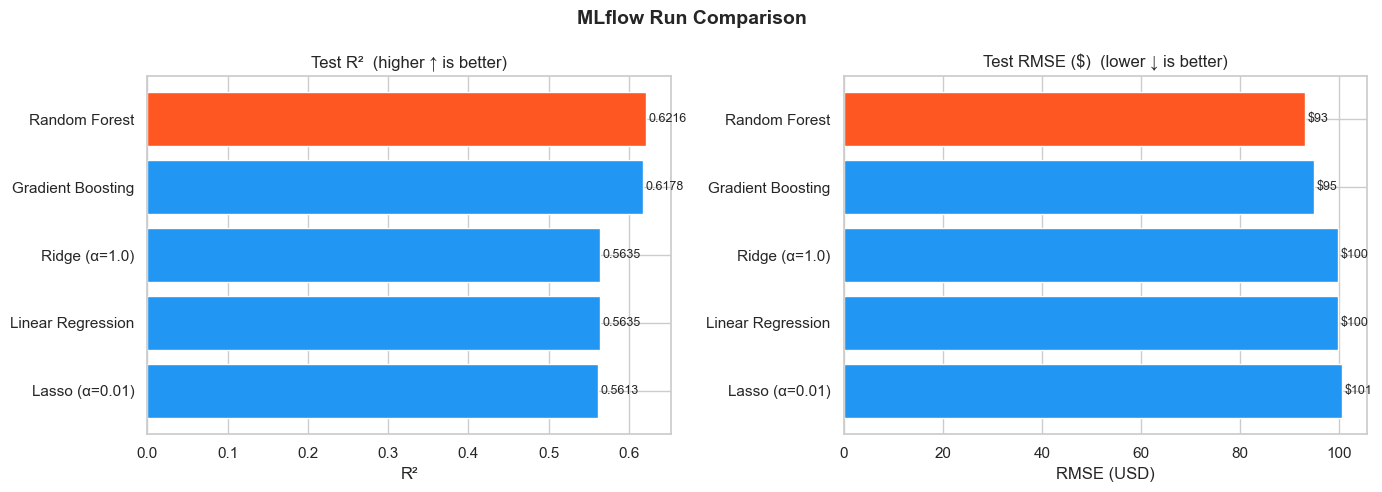

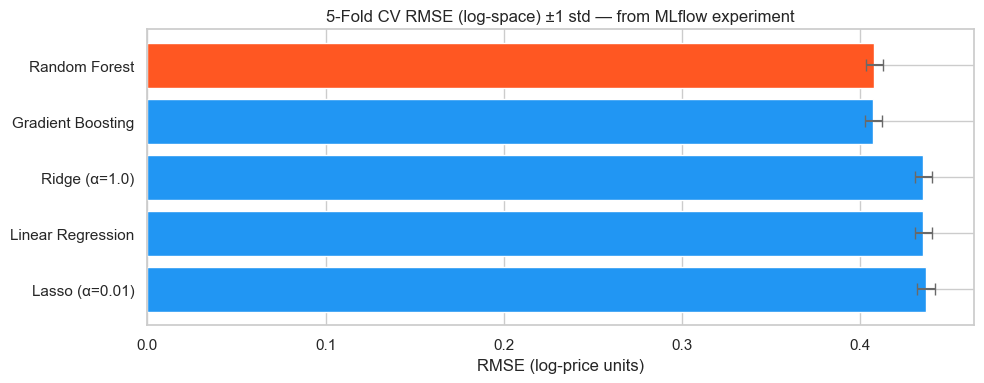

In [52]:
# ── Query all runs and build a comparison table ───────────────────────────────
runs_df = mlflow.search_runs(
    experiment_names=[EXPERIMENT_NAME],
    order_by=["metrics.test_r2 DESC"],
)

METRIC_RENAME = {
    "tags.mlflow.runName":    "Model",
    "metrics.cv_rmse_mean":   "CV RMSE mean",
    "metrics.cv_rmse_std":    "CV RMSE std",
    "metrics.cv_r2_mean":     "CV R² mean",
    "metrics.test_rmse_log":  "Test RMSE (log)",
    "metrics.test_mae_log":   "Test MAE (log)",
    "metrics.test_r2":        "Test R²",
    "metrics.test_rmse_usd":  "Test RMSE ($)",
    "metrics.train_time_s":   "Train time (s)",
}

available_cols = [c for c in METRIC_RENAME if c in runs_df.columns]
comparison = (
    runs_df[available_cols + ["run_id"]]
    .rename(columns=METRIC_RENAME)
)

print("\n" + "=" * 70)
print("MLFLOW RUN COMPARISON — sorted by Test R² (descending)")
print("=" * 70)
display(comparison.set_index("Model").drop(columns="run_id"))

# ── Identify the best run ─────────────────────────────────────────────────────
best_run_row  = runs_df.sort_values("metrics.test_r2", ascending=False).iloc[0]
best_run_id   = best_run_row["run_id"]
best_run_name = best_run_row["tags.mlflow.runName"]
best_r2       = best_run_row["metrics.test_r2"]
best_rmse_usd = best_run_row["metrics.test_rmse_usd"]

print(f"\n  Best run  : '{best_run_name}'")
print(f"  Run ID   : {best_run_id}")
print(f"  Test R²  : {best_r2:.4f}")
print(f"  RMSE ($) : ${best_rmse_usd:.2f}")

# ── Comparison bar charts ─────────────────────────────────────────────────────
model_names = comparison["Model"].tolist()
r2_vals     = comparison["Test R²"].tolist()
usd_vals    = comparison["Test RMSE ($)"].tolist()
bar_colors  = ["#FF5722" if n == best_run_name else "#2196F3" for n in model_names]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("MLflow Run Comparison", fontsize=14, fontweight="bold")

# R² (higher is better)
axes[0].barh(model_names[::-1], r2_vals[::-1], color=bar_colors[::-1], edgecolor="white")
axes[0].set_title("Test R²  (higher ↑ is better)")
axes[0].set_xlabel("R²")
for bar, val in zip(axes[0].patches, r2_vals[::-1]):
    axes[0].text(bar.get_width() + 0.003, bar.get_y() + bar.get_height() / 2,
                 f"{val:.4f}", va="center", fontsize=9)

# RMSE in USD (lower is better)
axes[1].barh(model_names[::-1], usd_vals[::-1], color=bar_colors[::-1], edgecolor="white")
axes[1].set_title("Test RMSE ($)  (lower ↓ is better)")
axes[1].set_xlabel("RMSE (USD)")
for bar, val in zip(axes[1].patches, usd_vals[::-1]):
    axes[1].text(bar.get_width() + 0.5, bar.get_y() + bar.get_height() / 2,
                 f"${val:.0f}", va="center", fontsize=9)

plt.tight_layout()
plt.show()

# ── CV RMSE error-bar chart from MLflow data ──────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 4))
ax.barh(
    model_names[::-1],
    comparison["CV RMSE mean"].tolist()[::-1],
    xerr=comparison["CV RMSE std"].tolist()[::-1],
    color=bar_colors[::-1],
    edgecolor="white",
    capsize=4,
    error_kw={"elinewidth": 1.5, "ecolor": "dimgray"},
)
ax.set_title("5-Fold CV RMSE (log-space) ±1 std — from MLflow experiment")
ax.set_xlabel("RMSE (log-price units)")
plt.tight_layout()
plt.show()


In [53]:
from mlflow.tracking import MlflowClient

client = MlflowClient()

# ── Register the best model in the MLflow Model Registry ─────────────────────
model_uri = f"runs:/{best_run_id}/model"
logger.info("Registering model from run '%s'  (run_id=%s) …", best_run_name, best_run_id)

registered_model = mlflow.register_model(
    model_uri=model_uri,
    name=REGISTERED_MODEL_NAME,
)

logger.info(
    "Registered '%s' as version %s.",
    REGISTERED_MODEL_NAME,
    registered_model.version,
)

# ── Add description and tags ──────────────────────────────────────────────────
client.update_registered_model(
    name=REGISTERED_MODEL_NAME,
    description=(
        f"Airbnb NYC nightly-price predictor trained on AB_NYC_2019 (48 k listings). "
        f"Best algorithm: {best_run_name}.  "
        f"Target: log_price (np.log1p of USD price).  "
        f"Data source: s3://staywise1/airbnb/raw_data/AB_NYC_2019.csv."
    ),
)

client.set_model_version_tag(REGISTERED_MODEL_NAME, registered_model.version, "algorithm",     best_run_name)
client.set_model_version_tag(REGISTERED_MODEL_NAME, registered_model.version, "test_r2",       str(round(best_r2, 4)))
client.set_model_version_tag(REGISTERED_MODEL_NAME, registered_model.version, "test_rmse_usd", str(round(best_rmse_usd, 2)))
client.set_model_version_tag(REGISTERED_MODEL_NAME, registered_model.version, "n_features",    str(len(FEATURE_COLS)))

# ── Promote to 'production' alias (MLflow ≥ 2.9) or stage (legacy) ───────────
try:
    # MLflow 2.9+ uses aliases instead of stages
    client.set_registered_model_alias(
        name=REGISTERED_MODEL_NAME,
        alias="production",
        version=registered_model.version,
    )
    production_uri = f"models:/{REGISTERED_MODEL_NAME}@production"
    logger.info("Alias 'production' set → version %s  (MLflow 2.9+ API).", registered_model.version)
except AttributeError:
    # Fallback for older MLflow
    client.transition_model_version_stage(
        name=REGISTERED_MODEL_NAME,
        version=registered_model.version,
        stage="Production",
        archive_existing_versions=True,
    )
    production_uri = f"models:/{REGISTERED_MODEL_NAME}/Production"
    logger.info("Stage 'Production' set → version %s  (legacy API).", registered_model.version)

# ── Reload model from registry and run sample predictions ────────────────────
logger.info("Loading model back from registry URI: %s", production_uri)
loaded_model = mlflow.sklearn.load_model(production_uri)

# Prepare 5 sample inputs — apply scaling if the best model required it
best_use_scaled_reg = next(s for n, _, s in MODELS if n == best_run_name)
sample_X = (X_test_scaled if best_use_scaled_reg else X_test)[:5]

sample_preds_log = loaded_model.predict(sample_X)
sample_preds_usd = np.expm1(sample_preds_log)
actual_usd       = np.expm1(y_test[:5])

print("\n" + "=" * 65)
print("REGISTRY VERIFICATION — 5 sample predictions")
print("=" * 65)
verification_df = pd.DataFrame({
    "actual_price ($)":    actual_usd.round(2),
    "predicted_price ($)": sample_preds_usd.round(2),
    "abs_error ($)":       np.abs(actual_usd - sample_preds_usd).round(2),
})
display(verification_df)

# ── Step 4 summary ────────────────────────────────────────────────────────────
print("\n" + "=" * 65)
print("STEP 4 SUMMARY")
print("=" * 65)
print(f"  Experiment      : {EXPERIMENT_NAME}")
print(f"  Runs logged     : {len(MODELS)}")
print(f"  Best model      : {best_run_name}")
print(f"  Test R²         : {best_r2:.4f}")
print(f"  Test RMSE ($)   : ${best_rmse_usd:.2f}")
print(f"  Registry name   : {REGISTERED_MODEL_NAME}")
print(f"  Version         : {registered_model.version}")
print(f"  URI             : {production_uri}")
print(f"\n  → Model ready for Step 5: final evaluation & selection.")


2026-04-03 23:42:43  INFO      Registering model from run 'Random Forest'  (run_id=bd28f588d58d4860a6932db4c52ff8b3) …
Successfully registered model 'airbnb-price-predictor'.
2026/04/03 23:42:43 WARNING mlflow.tracking._model_registry.fluent: Run with id bd28f588d58d4860a6932db4c52ff8b3 has no artifacts at artifact path 'model', registering model based on models:/m-1fa2699676cf4b58bacdd6b5790a8b99 instead
Created version '1' of model 'airbnb-price-predictor'.
2026-04-03 23:42:43  INFO      Registered 'airbnb-price-predictor' as version 1.
2026-04-03 23:42:43  INFO      Alias 'production' set → version 1  (MLflow 2.9+ API).
2026-04-03 23:42:43  INFO      Loading model back from registry URI: models:/airbnb-price-predictor@production



REGISTRY VERIFICATION — 5 sample predictions


,actual_price ($),predicted_price ($),abs_error ($)
0,99.0,102.07,3.07
1,90.0,84.95,5.05
2,80.0,94.39,14.39
3,60.0,59.40,0.60
4,90.0,103.38,13.38



STEP 4 SUMMARY
  Experiment      : airbnb-price-prediction
  Runs logged     : 5
  Best model      : Random Forest
  Test R²         : 0.6216
  Test RMSE ($)   : $93.09
  Registry name   : airbnb-price-predictor
  Version         : 1
  URI             : models:/airbnb-price-predictor@production

  → Model ready for Step 5: final evaluation & selection.


---
## Step 4b — Random Forest Hyperparameter Tuning Experiment (MLflow)

**Goal:** Systematically vary the three most impactful Random Forest hyperparameters across a grid, log every combination as a separate MLflow run, and identify the configuration that maximises price-prediction accuracy.

### Why Random Forest?
Step 4 confirmed RF as one of the top-performing models. Hyperparameter tuning it is the natural next step before production registration.

### Hyperparameters explored
| Parameter | Values | Effect on model |
|-----------|--------|-----------------|
| `n_estimators` | 100, 200, 300 | Ensemble size — more trees reduce variance but with diminishing returns and higher compute cost |
| `max_depth` | 10, 20, `None` | Tree depth — deeper trees are more expressive but risk overfitting and slower inference |
| `min_samples_leaf` | 2, 4, 8 | Leaf regularisation — higher values smooth predictions and reduce overfit |

**Grid size:** 3 × 3 × 3 = **27 runs** logged to experiment `rf-hyperparameter-tuning`

### What gets logged per run (same pattern as Step 4)
- **Parameters**: all three HP values + feature count + target
- **Metrics**: 3-fold CV RMSE/R², Test RMSE (log/USD), MAE, R², train time
- **Model**: fitted `RandomForestRegressor` via `mlflow.sklearn.log_model()`

> **Note:** 3-fold CV (vs 5-fold in Step 4) is used to keep the 27-run grid feasible. The held-out test metrics are the primary comparison criterion.

In [55]:
from sklearn.model_selection import ParameterGrid

# ── Tuning experiment configuration ──────────────────────────────────────────
RF_TUNING_EXPERIMENT: str = "rf-hyperparameter-tuning"
mlflow.set_experiment(RF_TUNING_EXPERIMENT)
logger.info("MLflow experiment : '%s'", RF_TUNING_EXPERIMENT)

# ── Hyperparameter grid ───────────────────────────────────────────────────────
# Step 3 baseline: n_estimators=200, max_depth=20, min_samples_leaf=4
# The grid explores variations around that baseline on three independent axes.
RF_PARAM_GRID: dict[str, list] = {
    "n_estimators":     [100, 200, 300],   # ensemble size
    "max_depth":        [10, 20, None],    # None → fully grown (unconstrained)
    "min_samples_leaf": [2, 4, 8],         # leaf regularisation
}

hp_combos = list(ParameterGrid(RF_PARAM_GRID))
logger.info(
    "Grid: %d combinations  |  %s",
    len(hp_combos),
    "  ×  ".join(f"{k}({len(v)} values)" for k, v in RF_PARAM_GRID.items()),
)

# ── Training loop ─────────────────────────────────────────────────────────────
rf_tune_results: list[dict] = []
rf_tune_run_ids: dict[str, str] = {}

# Constants: RF is scale-invariant → use raw (unscaled) features
_X_tr = X_train
_X_te = X_test

for i, params in enumerate(hp_combos, 1):
    # params["max_depth"] is None for the unconstrained case;
    # use a safe label that avoids int() conversion on None/NaN
    depth_label = str(params["max_depth"]) if params["max_depth"] is not None else "unlimited"
    run_name = (
        f"RF_n{params['n_estimators']}"
        f"_d{depth_label}"
        f"_l{params['min_samples_leaf']}"
    )
    logger.info("[%2d/%2d] %s", i, len(hp_combos), run_name)

    rf_model = RandomForestRegressor(
        n_estimators=params["n_estimators"],
        max_depth=params["max_depth"],
        min_samples_leaf=params["min_samples_leaf"],
        n_jobs=-1,
        random_state=42,
    )

    with mlflow.start_run(run_name=run_name) as run:

        # ── Parameters ────────────────────────────────────────────────────────
        mlflow.log_param("n_estimators",     params["n_estimators"])
        # Log max_depth as string so None becomes "unlimited" instead of null
        mlflow.log_param("max_depth",        depth_label)
        mlflow.log_param("min_samples_leaf", params["min_samples_leaf"])
        mlflow.log_param("n_features",       len(FEATURE_COLS))
        mlflow.log_param("target",           TARGET)
        is_baseline = (
            params["n_estimators"] == 200
            and params["max_depth"] == 20
            and params["min_samples_leaf"] == 4
        )
        mlflow.log_param("is_step3_baseline", is_baseline)

        # ── 3-fold CV on training set (3 vs 5 folds for grid-search speed) ────
        cv_m = cross_validate_model(rf_model, _X_tr, y_train, cv_folds=3)
        mlflow.log_metrics({
            "cv_rmse_mean": cv_m["cv_rmse_mean"],
            "cv_rmse_std":  cv_m["cv_rmse_std"],
            "cv_r2_mean":   cv_m["cv_r2_mean"],
        })

        # ── Full fit + hold-out test evaluation ───────────────────────────────
        test_m = evaluate_on_split(rf_model, _X_tr, y_train, _X_te, y_test)
        mlflow.log_metrics({
            "test_rmse_log": test_m["rmse_log"],
            "test_mae_log":  test_m["mae_log"],
            "test_r2":       test_m["r2"],
            "test_rmse_usd": test_m["rmse_usd"],
            "train_time_s":  test_m["train_time_s"],
        })

        # ── Model artefact ────────────────────────────────────────────────────
        mlflow.sklearn.log_model(
            sk_model=rf_model,
            artifact_path="model",
            input_example=_X_te[:3],
        )

        # ── Feature importance plot ────────────────────────────────────────────
        fig_hp, ax_hp = plt.subplots(figsize=(10, 5))
        plot_feature_importance(rf_model, run_name, FEATURE_COLS, top_n=12, ax=ax_hp)
        plt.tight_layout()
        imp_path = os.path.join(tempfile.gettempdir(), f"imp_{run_name}.png")
        fig_hp.savefig(imp_path, dpi=100, bbox_inches="tight")
        plt.close(fig_hp)
        mlflow.log_artifact(imp_path, artifact_path="plots")

        rf_tune_run_ids[run_name] = run.info.run_id

    rf_tune_results.append({
        "run_name":    run_name,
        "is_baseline": is_baseline,
        "n_estimators": params["n_estimators"],
        # Store depth as the string label so the column is always str, never NaN
        "max_depth":    depth_label,
        "min_samples_leaf": params["min_samples_leaf"],
        **cv_m,
        **test_m,
    })

# ── Build results DataFrame ────────────────────────────────────────────────────
rf_tune_df = pd.DataFrame(rf_tune_results).sort_values("r2", ascending=False).reset_index(drop=True)
# max_depth is already stored as a string label ("10", "20", "unlimited")
rf_tune_df["depth_label"] = rf_tune_df["max_depth"]

logger.info(
    "Sweep complete.  Best R²=%.4f  RMSE=$%.2f  ← %s",
    rf_tune_df["r2"].iloc[0],
    rf_tune_df["rmse_usd"].iloc[0],
    rf_tune_df["run_name"].iloc[0],
)


2026-04-04 00:10:05  INFO      MLflow experiment : 'rf-hyperparameter-tuning'
2026-04-04 00:10:05  INFO      Grid: 27 combinations  |  n_estimators(3 values)  ×  max_depth(3 values)  ×  min_samples_leaf(3 values)
2026-04-04 00:10:05  INFO      [ 1/27] RF_n100_d10_l2
2026/04/04 00:10:08 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/04/04 00:10:08 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


2026-04-04 00:10:11  INFO      [ 2/27] RF_n200_d10_l2
2026/04/04 00:10:17 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/04/04 00:10:17 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


2026-04-04 00:10:21  INFO      [ 3/27] RF_n300_d10_l2
2026/04/04 00:10:30 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/04/04 00:10:30 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


2026-04-04 00:10:33  INFO      [ 4/27] RF_n100_d10_l4
2026/04/04 00:10:36 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/04/04 00:10:36 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


2026-04-04 00:10:40  INFO      [ 5/27] RF_n200_d10_l4
2026/04/04 00:10:46 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/04/04 00:10:46 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


...

2026-04-04 00:15:17  INFO      [24/27] RF_n300_dunlimited_l4
2026/04/04 00:15:34 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/04/04 00:15:35 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


2026-04-04 00:15:39  INFO      [25/27] RF_n100_dunlimited_l8
2026/04/04 00:15:44 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/04/04 00:15:44 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


2026-04-04 00:15:48  INFO      [26/27] RF_n200_dunlimited_l8
2026/04/04 00:15:59 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/04/04 00:15:59 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


2026-04-04 00:16:03  INFO      [27/27] RF_n300_dunlimited_l8
2026/04/04 00:16:18 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/04/04 00:16:18 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


2026-04-04 00:16:21  INFO      Sweep complete.  Best R²=0.6222  RMSE=$93.10  ← RF_n300_d20_l4


2026-04-04 00:16:41  INFO      Queried 54 runs from experiment 'rf-hyperparameter-tuning'.



TOP 10 CONFIGURATIONS — rf-hyperparameter-tuning


,Run,n_estimators,max_depth,min_samples_leaf,CV R² (3-fold),Test R²,Test RMSE ($),Train time (s)
0,RF_n300_d20_l4,300,20,4,0.6262,0.6222,93.10,3.52
1,RF_n200_d20_l4,200,20,4,0.6258,0.6216,93.09,2.44
2,RF_n300_d20_l2,300,20,2,0.6246,0.6215,92.83,3.76
3,RF_n300_dunlimited_l4,300,unlimited,4,0.6257,0.6214,93.10,3.64
4,RF_n200_d20_l2,200,20,2,0.6241,0.6213,92.78,2.57
5,RF_n300_d20_l8,300,20,8,0.6259,0.6211,93.54,3.24
6,RF_n300_dunlimited_l8,300,unlimited,8,0.6258,0.6209,93.53,3.07
7,RF_n200_dunlimited_l4,200,unlimited,4,0.6253,0.6207,93.10,2.28
8,RF_n200_d20_l8,200,20,8,0.6256,0.6207,93.53,2.13
9,RF_n200_dunlimited_l8,200,unlimited,8,0.6254,0.6205,93.52,2.27



  Step 3 baseline (n=200, d=20, leaf=4) → Rank #2  R²=0.6216  RMSE=$93.09


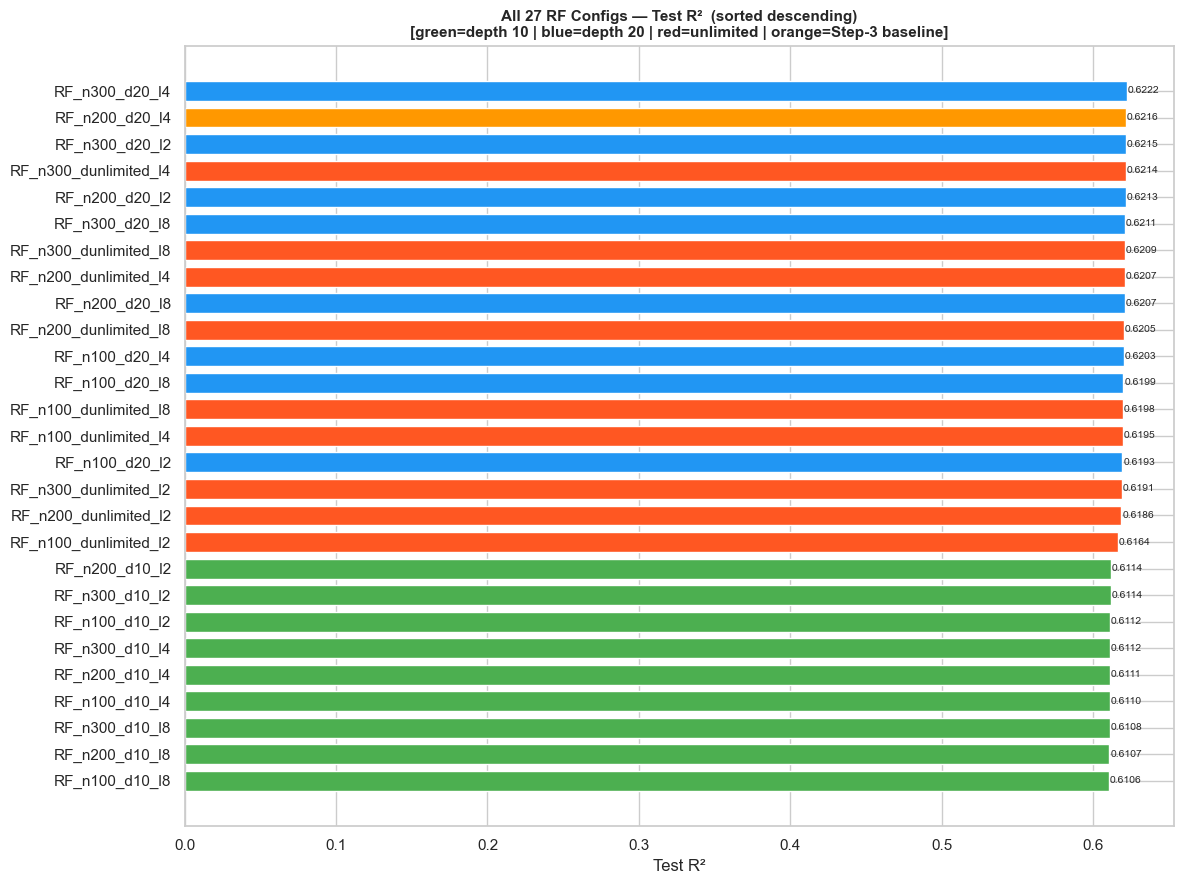

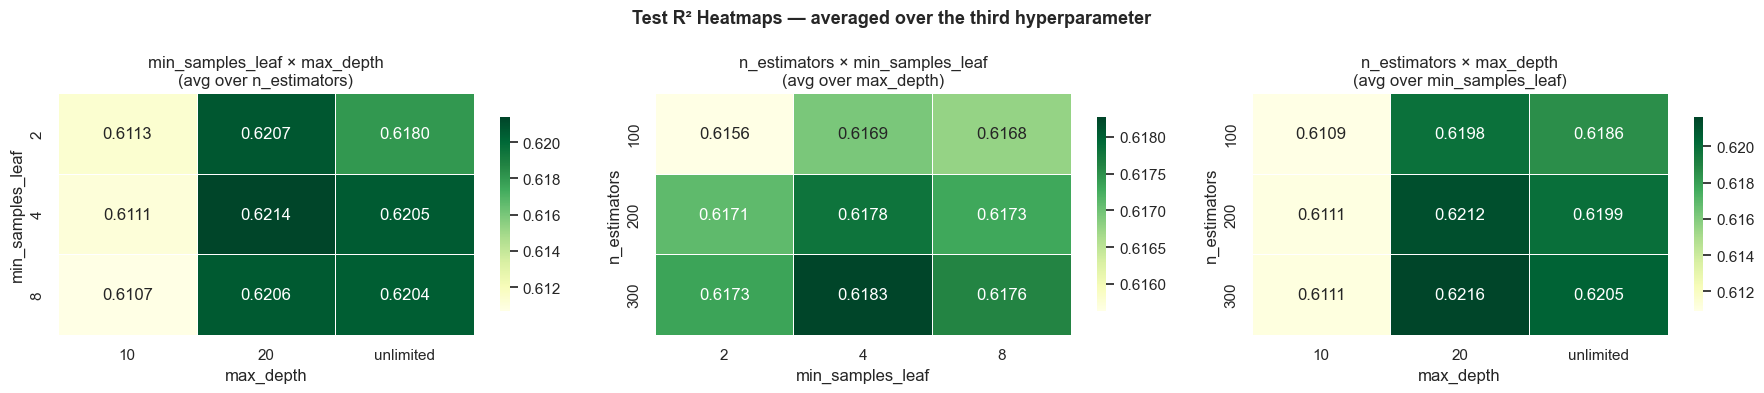

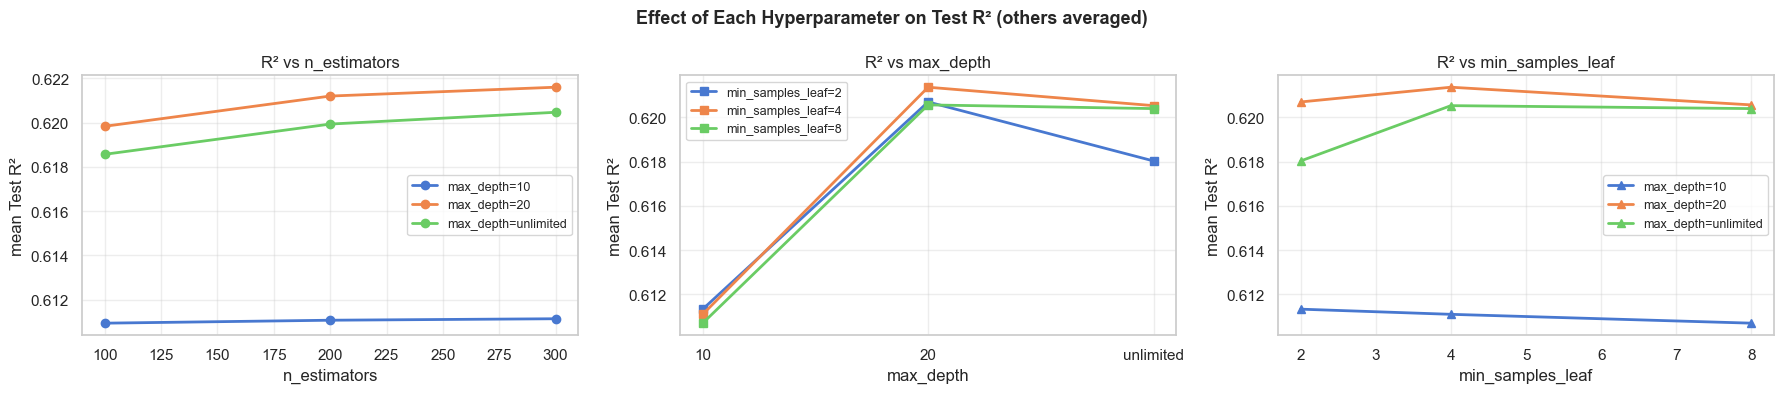

In [56]:
# ── Query runs from MLflow ────────────────────────────────────────────────────
rf_runs_mlflow = mlflow.search_runs(
    experiment_names=[RF_TUNING_EXPERIMENT],
    order_by=["metrics.test_r2 DESC"],
)
logger.info("Queried %d runs from experiment '%s'.", len(rf_runs_mlflow), RF_TUNING_EXPERIMENT)

# ── Top-10 leaderboard ────────────────────────────────────────────────────────
top10_cols = {
    "run_name":    "Run",
    "n_estimators": "n_estimators",
    "depth_label": "max_depth",
    "min_samples_leaf": "min_samples_leaf",
    "cv_r2_mean":  "CV R² (3-fold)",
    "r2":          "Test R²",
    "rmse_usd":    "Test RMSE ($)",
    "train_time_s": "Train time (s)",
}
print("\n" + "=" * 75)
print(f"TOP 10 CONFIGURATIONS — {RF_TUNING_EXPERIMENT}")
print("=" * 75)
display(rf_tune_df.head(10)[list(top10_cols.keys())].rename(columns=top10_cols).reset_index(drop=True))

# Baseline row for reference
baseline_row = rf_tune_df[rf_tune_df["is_baseline"]]
if not baseline_row.empty:
    brow = baseline_row.iloc[0]
    rank = rf_tune_df[rf_tune_df["is_baseline"]].index[0] + 1
    print(f"\n  Step 3 baseline (n=200, d=20, leaf=4) → Rank #{rank}  "
          f"R²={brow['r2']:.4f}  RMSE=${brow['rmse_usd']:.2f}")

# ── Sorted bar chart — all 27 runs ────────────────────────────────────────────
depth_palette = {"10": "#4CAF50", "20": "#2196F3", "unlimited": "#FF5722"}

fig, ax = plt.subplots(figsize=(12, 9))
bar_c_all = [
    "#FF9800" if row["is_baseline"]
    else depth_palette.get(row["depth_label"], "#9E9E9E")
    for _, row in rf_tune_df.iterrows()
]
ax.barh(rf_tune_df["run_name"], rf_tune_df["r2"], color=bar_c_all,
        edgecolor="white", height=0.75)
ax.set_title("All 27 RF Configs — Test R²  (sorted descending)\n"
             "[green=depth 10 | blue=depth 20 | red=unlimited | orange=Step-3 baseline]",
             fontsize=11, fontweight="bold")
ax.set_xlabel("Test R²")
ax.invert_yaxis()
for bar, val in zip(ax.patches, rf_tune_df["r2"]):
    ax.text(bar.get_width() + 0.0005, bar.get_y() + bar.get_height() / 2,
            f"{val:.4f}", va="center", fontsize=7.5)
plt.tight_layout()
plt.show()

# ── Heatmaps: R² as a function of each pair of hyperparameters ───────────────
# Column order for max_depth: preserve numeric order, put "unlimited" last
depth_order = (
    [str(int(d)) for d in sorted(d for d in RF_PARAM_GRID["max_depth"] if d is not None)]
    + ["unlimited"]
)

fig, axes = plt.subplots(1, 3, figsize=(18, 4))
fig.suptitle("Test R² Heatmaps — averaged over the third hyperparameter",
             fontsize=13, fontweight="bold")

# ── Heatmap 1: min_samples_leaf × max_depth  (avg over n_estimators)
pivot1 = rf_tune_df.pivot_table(
    values="r2", index="min_samples_leaf", columns="depth_label", aggfunc="mean"
)[depth_order]
sns.heatmap(pivot1, annot=True, fmt=".4f", cmap="YlGn", ax=axes[0],
            linewidths=0.5, cbar_kws={"shrink": 0.8})
axes[0].set_title("min_samples_leaf × max_depth\n(avg over n_estimators)")
axes[0].set_xlabel("max_depth")
axes[0].set_ylabel("min_samples_leaf")

# ── Heatmap 2: n_estimators × min_samples_leaf  (avg over max_depth)
pivot2 = rf_tune_df.pivot_table(
    values="r2", index="n_estimators", columns="min_samples_leaf", aggfunc="mean"
)
sns.heatmap(pivot2, annot=True, fmt=".4f", cmap="YlGn", ax=axes[1],
            linewidths=0.5, cbar_kws={"shrink": 0.8})
axes[1].set_title("n_estimators × min_samples_leaf\n(avg over max_depth)")
axes[1].set_xlabel("min_samples_leaf")
axes[1].set_ylabel("n_estimators")

# ── Heatmap 3: n_estimators × max_depth  (avg over min_samples_leaf)
pivot3 = rf_tune_df.pivot_table(
    values="r2", index="n_estimators", columns="depth_label", aggfunc="mean"
)[depth_order]
sns.heatmap(pivot3, annot=True, fmt=".4f", cmap="YlGn", ax=axes[2],
            linewidths=0.5, cbar_kws={"shrink": 0.8})
axes[2].set_title("n_estimators × max_depth\n(avg over min_samples_leaf)")
axes[2].set_xlabel("max_depth")
axes[2].set_ylabel("n_estimators")

plt.tight_layout()
plt.show()

# ── Line plots: effect of each HP on R² while averaging the others ────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 4))
fig.suptitle("Effect of Each Hyperparameter on Test R² (others averaged)",
             fontsize=13, fontweight="bold")

# Plot 1: R² vs n_estimators, one line per max_depth
for depth_lbl in depth_order:
    grp = rf_tune_df[rf_tune_df["depth_label"] == depth_lbl]
    trend = grp.groupby("n_estimators")["r2"].mean()
    axes[0].plot(trend.index, trend.values, marker="o", linewidth=2,
                 label=f"max_depth={depth_lbl}")
axes[0].set_title("R² vs n_estimators")
axes[0].set_xlabel("n_estimators")
axes[0].set_ylabel("mean Test R²")
axes[0].legend(fontsize=9)
axes[0].grid(True, alpha=0.35)

# Plot 2: R² vs max_depth, one line per min_samples_leaf
for leaf in sorted(RF_PARAM_GRID["min_samples_leaf"]):
    grp = rf_tune_df[rf_tune_df["min_samples_leaf"] == leaf]
    trend = grp.groupby("depth_label")["r2"].mean().reindex(depth_order)
    axes[1].plot(depth_order, trend.values, marker="s", linewidth=2,
                 label=f"min_samples_leaf={leaf}")
axes[1].set_title("R² vs max_depth")
axes[1].set_xlabel("max_depth")
axes[1].set_ylabel("mean Test R²")
axes[1].legend(fontsize=9)
axes[1].grid(True, alpha=0.35)

# Plot 3: R² vs min_samples_leaf, one line per max_depth
for depth_lbl in depth_order:
    grp = rf_tune_df[rf_tune_df["depth_label"] == depth_lbl]
    trend = grp.groupby("min_samples_leaf")["r2"].mean()
    axes[2].plot(trend.index, trend.values, marker="^", linewidth=2,
                 label=f"max_depth={depth_lbl}")
axes[2].set_title("R² vs min_samples_leaf")
axes[2].set_xlabel("min_samples_leaf")
axes[2].set_ylabel("mean Test R²")
axes[2].legend(fontsize=9)
axes[2].grid(True, alpha=0.35)

plt.tight_layout()
plt.show()


In [57]:
# ── Best tuned configuration ──────────────────────────────────────────────────
best_tune     = rf_tune_df.iloc[0]
best_tune_name = best_tune["run_name"]
best_tune_id  = rf_tune_run_ids[best_tune_name]

logger.info(
    "Best tuned config: %s  |  Test R²=%.4f  |  RMSE=$%.2f  |  run_id=%s",
    best_tune_name,
    best_tune["r2"],
    best_tune["rmse_usd"],
    best_tune_id,
)

# ── Compare tuned vs Step 3 baseline ─────────────────────────────────────────
baseline_row = rf_tune_df[rf_tune_df["is_baseline"]]
print("\n" + "=" * 65)
print("TUNING IMPACT vs STEP 3 BASELINE")
print("=" * 65)
if not baseline_row.empty:
    base = baseline_row.iloc[0]
    delta_r2  = float(best_tune["r2"])  - float(base["r2"])
    delta_usd = float(best_tune["rmse_usd"]) - float(base["rmse_usd"])
    print(f"  Baseline  (n=200, d=20, leaf=4)")
    print(f"    Test R²      : {base['r2']:.4f}")
    print(f"    Test RMSE ($): ${base['rmse_usd']:.2f}")
    print(f"\n  Best tuned ({best_tune_name})")
    print(f"    n_estimators   : {int(best_tune['n_estimators'])}")
    print(f"    max_depth      : {best_tune['max_depth']}")
    print(f"    min_samples_leaf: {int(best_tune['min_samples_leaf'])}")
    print(f"    Test R²        : {best_tune['r2']:.4f}  (Δ={delta_r2:+.4f})")
    print(f"    Test RMSE ($)  : ${best_tune['rmse_usd']:.2f}  (Δ=${delta_usd:+.2f})")
else:
    print(f"  Best tuned: {best_tune_name}")
    print(f"    Test R²  : {best_tune['r2']:.4f}")
    print(f"    RMSE ($) : ${best_tune['rmse_usd']:.2f}")

# ── Register best tuned model as a new version ────────────────────────────────
tune_model_uri = f"runs:/{best_tune_id}/model"
logger.info("Registering tuned model → '%s' …", REGISTERED_MODEL_NAME)

tuned_version = mlflow.register_model(
    model_uri=tune_model_uri,
    name=REGISTERED_MODEL_NAME,
)
logger.info(
    "Registered as version %s  (source: %s).",
    tuned_version.version,
    RF_TUNING_EXPERIMENT,
)

# Version metadata
client.set_model_version_tag(REGISTERED_MODEL_NAME, tuned_version.version, "source",            RF_TUNING_EXPERIMENT)
client.set_model_version_tag(REGISTERED_MODEL_NAME, tuned_version.version, "n_estimators",     str(int(best_tune["n_estimators"])))
client.set_model_version_tag(REGISTERED_MODEL_NAME, tuned_version.version, "max_depth",        str(best_tune["max_depth"]))
client.set_model_version_tag(REGISTERED_MODEL_NAME, tuned_version.version, "min_samples_leaf", str(int(best_tune["min_samples_leaf"])))
client.set_model_version_tag(REGISTERED_MODEL_NAME, tuned_version.version, "test_r2",          str(round(float(best_tune["r2"]), 4)))
client.set_model_version_tag(REGISTERED_MODEL_NAME, tuned_version.version, "test_rmse_usd",    str(round(float(best_tune["rmse_usd"]), 2)))

# ── Promote to production (overwrites Step 4 version if better) ───────────────
try:
    client.set_registered_model_alias(
        name=REGISTERED_MODEL_NAME,
        alias="production",
        version=tuned_version.version,
    )
    tuned_prod_uri = f"models:/{REGISTERED_MODEL_NAME}@production"
    logger.info("'production' alias → version %s  (MLflow 2.9+ API).", tuned_version.version)
except AttributeError:
    client.transition_model_version_stage(
        name=REGISTERED_MODEL_NAME,
        version=tuned_version.version,
        stage="Production",
        archive_existing_versions=True,
    )
    tuned_prod_uri = f"models:/{REGISTERED_MODEL_NAME}/Production"
    logger.info("Stage 'Production' → version %s  (legacy API).", tuned_version.version)

# ── Verify: reload and predict ────────────────────────────────────────────────
tuned_loaded = mlflow.sklearn.load_model(tuned_prod_uri)
sample_preds_tuned = np.expm1(tuned_loaded.predict(_X_te[:5]))
actual_prices      = np.expm1(y_test[:5])

print("\n" + "=" * 65)
print("TUNED MODEL VERIFICATION — 5 sample predictions")
print("=" * 65)
display(pd.DataFrame({
    "actual_price ($)":    actual_prices.round(2),
    "predicted_price ($)": sample_preds_tuned.round(2),
    "abs_error ($)":       np.abs(actual_prices - sample_preds_tuned).round(2),
}))

# ── Step 4b summary ───────────────────────────────────────────────────────────
all_versions = client.search_model_versions(f"name='{REGISTERED_MODEL_NAME}'")
print("\n" + "=" * 65)
print("STEP 4b SUMMARY — RF HYPERPARAMETER TUNING")
print("=" * 65)
print(f"  Tuning experiment : {RF_TUNING_EXPERIMENT}")
print(f"  Runs logged       : {len(hp_combos)}")
print(f"  Best config       : {best_tune_name}")
print(f"    n_estimators    : {int(best_tune['n_estimators'])}")
print(f"    max_depth       : {best_tune['max_depth']}")
print(f"    min_samples_leaf: {int(best_tune['min_samples_leaf'])}")
print(f"  Test R²           : {best_tune['r2']:.4f}")
print(f"  Test RMSE ($)     : ${best_tune['rmse_usd']:.2f}")
print(f"  Registry versions : {len(all_versions)}  (v{tuned_version.version} is production)")
print(f"  Production URI    : {tuned_prod_uri}")
print(f"\n  → Best tuned RF registered and promoted to production.")


2026-04-04 00:18:31  INFO      Best tuned config: RF_n300_d20_l4  |  Test R²=0.6222  |  RMSE=$93.10  |  run_id=d3a07d0cd37d43d4b12db568fe8e6919
2026-04-04 00:18:31  INFO      Registering tuned model → 'airbnb-price-predictor' …
Registered model 'airbnb-price-predictor' already exists. Creating a new version of this model...
2026/04/04 00:18:31 WARNING mlflow.tracking._model_registry.fluent: Run with id d3a07d0cd37d43d4b12db568fe8e6919 has no artifacts at artifact path 'model', registering model based on models:/m-88fdeee6cc0b42d89dab89411c28ec45 instead
Created version '2' of model 'airbnb-price-predictor'.
2026-04-04 00:18:32  INFO      Registered as version 2  (source: rf-hyperparameter-tuning).
2026-04-04 00:18:32  INFO      'production' alias → version 2  (MLflow 2.9+ API).



TUNING IMPACT vs STEP 3 BASELINE
  Baseline  (n=200, d=20, leaf=4)
    Test R²      : 0.6216
    Test RMSE ($): $93.09

  Best tuned (RF_n300_d20_l4)
    n_estimators   : 300
    max_depth      : 20
    min_samples_leaf: 4
    Test R²        : 0.6222  (Δ=+0.0006)
    Test RMSE ($)  : $93.10  (Δ=$+0.01)

TUNED MODEL VERIFICATION — 5 sample predictions


,actual_price ($),predicted_price ($),abs_error ($)
0,99.0,101.01,2.01
1,90.0,85.01,4.99
2,80.0,95.05,15.05
3,60.0,59.11,0.89
4,90.0,101.83,11.83



STEP 4b SUMMARY — RF HYPERPARAMETER TUNING
  Tuning experiment : rf-hyperparameter-tuning
  Runs logged       : 27
  Best config       : RF_n300_d20_l4
    n_estimators    : 300
    max_depth       : 20
    min_samples_leaf: 4
  Test R²           : 0.6222
  Test RMSE ($)     : $93.10
  Registry versions : 2  (v2 is production)
  Production URI    : models:/airbnb-price-predictor@production

  → Best tuned RF registered and promoted to production.
